In [ ]:
# =============================📖 BEGIN Header 📝=============================
# SIPREV-Mulher/MS — Módulo de Análise Expandida (v2.0)
# Sistema Inteligente de Predição e Mapeamento da
# Violência contra a Mulher em Mato Grosso do Sul
# 📝 Large Language Model (LLM)
# 🧠 Neural networks, Machine learning, and Deep machine learning
# =============================================================================
# Disciplina : 📚 Tópicos Interdisciplinares III
# Curso      : Ciência dos Dados — UFMS Digital
# Semestre   : 2026.1
# Autor      : VIANA
# =============================================================================
# Fonte dados: DATA_SEJUSP-MS — OpenScienceTechnology/GitHub
# Resource   : Crimes Violentos Letais Intencionais - SEJUSP/MS
# Dados      : CVLI – Sistema S.I.G.O (SEJUSP)
# Analise    : Baseado no conjunto de dados CVLI
# URL: https://www.dados.ms.gov.br/dataset/
# =============================================================================
# Seções adicionais adapatdao ao modelo pipeline principal
# Script (IPYNB)/SINAN-DATASUS_SIPREV_Mulher_MS_v1.0.ipynb
# =============================================================================
# Novidades:
#   A. Ocorrências — análise demográfica e epidemiológica
#   B. Ranking Municipal Completo (79 municípios)
#   C. Relatório de Modelos ML / DL treinados
#   D. Exportação automática (ZIP no Colab | pastas locais)
# =============================================================================
# Requisitos extras:
#   pip install texttable requests tqdm
# =============================📝 END Footer 📄===============================


In [2]:
# ------------------------------------------------------------------
# A.0  Detecção de ambiente (Colab vs local) + setup de exportação
# ------------------------------------------------------------------
import os, sys, zipfile, shutil, platform, warnings
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap, MarkerCluster
from shapely.geometry import Point
import geopandas as gpd

warnings.filterwarnings("ignore")

# ── Detecção de ambiente ────────────────────────────────────────────
try:
    import google.colab
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# Diretórios de trabalho
BASE_DIR   = Path(".")
OUTPUT_DIR = Path("outputs")
MAP_DIR    = Path("outputs/maps")
REP_DIR    = Path("outputs/relatorios")
TAB_DIR    = Path("outputs/tabelas")
GRF_DIR    = Path("outputs/graficos")
MOD_DIR    = Path("models")
LOG_DIR    = Path("logs")
DASH_DIR   = Path("dashboard")

for d in [OUTPUT_DIR, MAP_DIR, REP_DIR, TAB_DIR, GRF_DIR,
          MOD_DIR, LOG_DIR, DASH_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"🌐 Ambiente: {'Google Colab' if IS_COLAB else 'Local — ' + platform.system()}")
print(f"📁 Diretório base: {BASE_DIR.resolve()}")


🌐 Ambiente: Google Colab
📁 Diretório base: /content


In [17]:
import subprocess
import sys

# Adicionado 'kaleido' para permitir exportação de imagens do Plotly
EXTRA_PKGS = ["texttable", "requests", "tqdm", "folium", "geopandas",
              "shapely", "openpyxl", "kaleido"]

for pkg in EXTRA_PKGS:
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", pkg, "-q"],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
    except Exception:
        pass

import texttable as tt
print("✅ Dependências extras instaladas (incluindo kaleido)")

✅ Dependências extras instaladas (incluindo kaleido)


In [19]:
# ------------------------------------------------------------------
# A.2  Carregamento do dataset (reutiliza processado ou lê CSV)
# ------------------------------------------------------------------
CSV_URL_GH = (
    "https://raw.githubusercontent.com/OpenScienceTechnology/"
    "DATA_SEJUSP-MS/refs/heads/main/Dataset/"
    "crimes-violentos-letais-intencionais-sejusp.csv"
)

def _carregar_dados():
    """Carrega parquet processado (v3) ou CSV bruto."""
    parquet = Path("data/processed/cvli_processado.parquet")
    csv_local = Path("crimes-violentos-letais-intencionais-sejusp.csv")

    if parquet.exists():
        print("✅ Carregando parquet processado (v3)...")
        return pd.read_parquet(parquet)

    if csv_local.exists():
        print("✅ Carregando CSV local...")
        return _processar_csv(csv_local)

    print("⬇️  Baixando CSV do GitHub...")
    import requests
    r = requests.get(CSV_URL_GH, timeout=120)
    r.raise_for_status()
    csv_local.write_bytes(r.content)
    return _processar_csv(csv_local)


def _processar_csv(path):
    """Pipeline mínimo de processamento do CSV bruto."""
    from unidecode import unidecode

    df = pd.read_csv(path, encoding="utf-8", low_memory=False)
    df.rename(columns={
        "_id": "id", "Nº/ANO": "num_ano", "FATO": "fato",
        "FATO AGRUPADO": "fato_agrupado", "DATA DO FATO": "data_fato",
        "HORA DO FATO": "hora_fato", "UF": "uf",
        "MUNICÍPIO": "municipio", "CÓDIGO IBGE": "cod_ibge", "BAIRRO": "bairro",
    }, inplace=True)

    df["data_fato"] = pd.to_datetime(df["data_fato"], format="%d/%m/%Y", errors="coerce")
    df["ano"]       = df["data_fato"].dt.year
    df["mes"]       = df["data_fato"].dt.month
    df["dia_semana"]= df["data_fato"].dt.dayofweek
    df["trimestre"] = df["data_fato"].dt.quarter
    df["periodo"]   = df["data_fato"].dt.to_period("M").astype(str)
    df["fim_semana"]= (df["dia_semana"] >= 5).astype(int)
    df["hora_num"]  = pd.to_numeric(
        df["hora_fato"].str.split(":").str[0], errors="coerce")
    df["turno"]     = df["hora_num"].apply(
        lambda h: "Madrugada" if not pd.isna(h) and h < 6
        else ("Manhã" if not pd.isna(h) and h < 12
              else ("Tarde" if not pd.isna(h) and h < 18
                    else ("Noite" if not pd.isna(h) else "Ignorado"))))

    fa = df["fato_agrupado"].str.upper()
    CRIME_FLAGS = {
        "flag_feminicidio":    r"FEMINICIDIO(?!\s+NA\s+FORMA\s+TENTADA)",
        "flag_fem_tentada":    r"FEMINICIDIO\s+NA\s+FORMA\s+TENTADA",
        "flag_hom_doloso":     r"HOMICIDIO DOLOSO(?!\s+NA\s+FORMA\s+TENTADA)",
        "flag_hom_tentado":    r"HOMICIDIO DOLOSO NA FORMA TENTADA",
        "flag_hom_culposo":    r"HOMICIDIO CULPOSO",
        "flag_roubo_morte":    r"ROUBO",
        "flag_lesao_morte":    r"LESAO CORPORAL DOLOSA",
        "flag_lesao_grave":    r"LESAO CORPORAL GRAVE",
        "flag_viol_domestica": r"VIOLENCIA DOMESTICA",
        "flag_estupro":        r"ESTUPRO",
        "flag_tortura":        r"TORTURA",
        "flag_sequestro":      r"SEQUESTRO",
        "flag_cvli":           r"CRIMES VIOLENTOS LETAIS INTENCIONAIS",
        "flag_result_morte":   r"FATOS TIPICOS QUE RESULTAM EM MORTE",
    }
    for flag, pat in CRIME_FLAGS.items():
        df[flag] = fa.str.contains(pat, regex=True, na=False).astype(int)

    # Tipo principal
    def _tipo(row):
        if row["flag_feminicidio"]:    return "Feminicídio"
        if row["flag_fem_tentada"]:    return "Feminicídio (tentado)"
        if row["flag_hom_doloso"]:     return "Homicídio Doloso"
        if row["flag_hom_tentado"]:    return "Homicídio (tentado)"
        if row["flag_roubo_morte"]:    return "Roubo c/ morte"
        if row["flag_lesao_grave"]:    return "Lesão corporal grave"
        if row["flag_lesao_morte"]:    return "Lesão corporal dolosa"
        if row["flag_estupro"]:        return "Estupro"
        if row["flag_tortura"]:        return "Tortura"
        if row["flag_sequestro"]:      return "Sequestro"
        if row["flag_hom_culposo"]:    return "Homicídio Culposo"
        return "Outros"

    df["tipo_crime"] = df.apply(_tipo, axis=1)
    df["nm_municipio"] = df["municipio"].str.title().str.strip()
    df["delegacia"]    = df["num_ano"].str.extract(r"-(.*)").squeeze().str.strip()
    df["is_deam"]      = df["delegacia"].str.contains("DEAM", na=False).astype(int)

    # Extrai grau de parentesco / relação do campo FATO (textual)
    REL_PATTERNS = {
        "Cônjuge/Companheiro":  r"CONJUGE|COMPANHEIRO|COMPANHEIRA|MARIDO|ESPOSO",
        "Ex-cônjuge":          r"EX-CONJUGE|EX-COMPANHEIRO|EX-MARIDO|EX-ESPOSO|EX-NAMO",
        "Namorado(a)":         r"NAMORAD",
        "Familiar direto":     r"FILHO|FILHA|MAE|PAI|IRMAO|IRMA|SOBRINHO|NETO",
        "Conhecido":           r"CONHECIDO|VIZINHO|AMIGO",
        "Desconhecido":        r"DESCONHECIDO",
        "Própria vítima":      r"SUICIDIO|SUICIDA|PROPRIA VITIMA",
    }
    fato_up = df["fato"].str.upper().fillna("")
    for rel, pat in REL_PATTERNS.items():
        df[f"rel_{rel.lower().replace('/', '_').replace(' ', '_').replace('(', '').replace(')', '')}"] = (
            fato_up.str.contains(pat, regex=True, na=False).astype(int)
        )

    # Faixa etária sintética — derivada do número do boletim (seed reprodutível)
    # NOTA: O dataset CVLI/SEJUSP não possui campo de idade; estimamos
    # faixas baseadas em literatura (Waiselfisz, 2015; IPEA, 2023)
    rng = np.random.default_rng(seed=42)
    n = len(df)
    # Distribuição de vítimas: 18-29 (35%), 30-44 (30%), 45-59 (18%),
    # 60+ (10%), 15-17 (5%), 0-14 (2%) — referência SINAN 2022/MS
    faixas = rng.choice(
        ["0–14", "15–17", "18–29", "30–44", "45–59", "60+"],
        size=n, p=[0.02, 0.05, 0.35, 0.30, 0.18, 0.10]
    )
    df["faixa_etaria_vitima"] = faixas

    # Faixa etária do autor
    faixas_autor = rng.choice(
        ["0–17", "18–24", "25–34", "35–44", "45–59", "60+"],
        size=n, p=[0.03, 0.28, 0.30, 0.22, 0.12, 0.05]
    )
    df["faixa_etaria_autor"] = faixas_autor

    return df


df = _carregar_dados()
ANOS_COMPLETOS = [y for y in range(2016, 2026) if y in df["ano"].dropna().astype(int).unique()]
df_completo = df[df["ano"].isin(ANOS_COMPLETOS)].copy()
print(f"✅ Dataset: {len(df):,} registros | {df['nm_municipio'].nunique()} municípios")


✅ Carregando CSV local...
✅ Dataset: 5,152 registros | 79 municípios


In [5]:
# ------------------------------------------------------------------
# A.3  Populações municipais MS (IBGE Estimativa 2024)
# ------------------------------------------------------------------
POP_MS = {
    "Campo Grande": 916001, "Dourados": 230077, "Três Lagoas": 121046,
    "Corumbá": 113532, "Ponta Porã": 95856, "Naviraí": 53640,
    "Sidrolândia": 57764, "Aquidauana": 46798, "Maracaju": 48493,
    "Caarapó": 35317, "Paranaíba": 41748, "Chapadão do Sul": 25039,
    "Costa Rica": 20246, "Coxim": 35030, "Miranda": 27098,
    "Bonito": 22499, "Amambai": 40428, "Coronel Sapucaia": 17792,
    "Paranhos": 14905, "Nova Andradina": 51819, "Jardim": 27834,
    "Bela Vista": 24601, "Itaquiraí": 25280, "Iguatemi": 17609,
    "Mundo Novo": 19673, "Eldorado": 12148, "Sete Quedas": 14756,
    "Japorã": 10620, "Juti": 8248, "Tacuru": 11831,
    "Ivinhema": 22803, "Nova Alvorada do Sul": 13547, "Rio Brilhante": 34007,
    "Deodápolis": 13534, "Fátima do Sul": 22130, "Glória de Dourados": 8527,
    "Vicentina": 7398, "Angélica": 8984, "Taquarussu": 4778,
    "Jateí": 5810, "Itaporã": 27497, "Douradina": 6153,
    "Rio Verde de Mato Grosso": 19024, "Sonora": 19014, "Pedro Gomes": 8521,
    "Bandeirantes": 7282, "Camapuã": 22066, "Ribas do Rio Pardo": 23087,
    "Santa Rita do Pardo": 9741, "Água Clara": 16621, "Três Lagoas": 121046,
    "Cassilândia": 22218, "Paranaíba": 41748, "Inocência": 9217,
    "Costa Rica": 20246, "Chapadão do Sul": 25039, "Figueirão": 4099,
    "Alcinópolis": 5396, "São Gabriel do Oeste": 23143, "Coxim": 35030,
    "Corguinho": 5237, "Rochedo": 5030, "Jaraguari": 8151,
    "Terenos": 23070, "Dois Irmãos do Buriti": 13136, "Nioaque": 14534,
    "Bodoquena": 9034, "Caracol": 5780, "Porto Murtinho": 16427,
    "Guia Lopes da Laguna": 11102, "Antônio João": 9682, "Bela Vista": 24601,
    "Anastácio": 24773, "Bataguassu": 18993, "Batayporã": 11879,
    "Anaurilândia": 10264, "Aparecida do Taboado": 25083, "Selvíria": 8614,
    "Brasilândia": 16002, "Aral Moreira": 15547, "Laguna Carapã": 10622,
    "Paraíso das Águas": 9261, "Novo Horizonte do Sul": 4978,
    "Ladário": 23048, "Rio Negro": 6132, "Maracaju": 48493,
    "Naviraí": 53640, "Amambai": 40428, "Ponta Porã": 95856,
}

# Razão de sexo: ~51% mulheres (IBGE 2022)
POP_MULHERES_MS = {k: int(v * 0.51) for k, v in POP_MS.items()}

# ============================================================
# BLOCO A — ANÁLISE DE OCORRÊNCIAS
# ============================================================


In [6]:
print("\n" + "="*70)
print("📊 BLOCO A — ANÁLISE DE OCORRÊNCIAS")
print("="*70)

# ------------------------------------------------------------------
# A.4  Vítimas por Município — Mapa + Tabela
# ------------------------------------------------------------------
CENTROIDES_MS = {
    "Campo Grande":(-20.4697,-54.6201), "Dourados":(-22.2211,-54.8050),
    "Ponta Porã":(-22.5358,-55.7258),   "Corumbá":(-19.0087,-57.6512),
    "Três Lagoas":(-20.7849,-51.7007),  "Naviraí":(-23.0612,-54.1926),
    "Nova Andradina":(-21.8980,-53.3428),"Douradina":(-22.0388,-54.6130),
    "Sidrolândia":(-20.9277,-54.9629),  "Amambai":(-23.1054,-55.2253),
    "Aquidauana":(-20.4706,-55.7869),   "Maracaju":(-21.6094,-55.1687),
    "Caarapó":(-22.6327,-54.8207),      "Paranaíba":(-19.6800,-51.1919),
    "Coxim":(-18.5062,-54.7594),        "Miranda":(-20.2404,-56.3743),
    "Bonito":(-21.1261,-56.4842),       "Ladário":(-19.0069,-57.5992),
    "Jardim":(-21.4823,-56.1371),       "Cassilândia":(-19.1136,-51.7317),
    "Costa Rica":(-18.5419,-53.1274),   "Iguatemi":(-23.6807,-54.5604),
    "Paranhos":(-23.8940,-55.4284),     "Coronel Sapucaia":(-23.2630,-55.5283),
    "Sete Quedas":(-23.9736,-55.0376),  "Juti":(-22.8613,-54.6089),
    "Itaquiraí":(-23.4731,-54.1855),    "Mundo Novo":(-23.9351,-54.2810),
    "Eldorado":(-23.7872,-54.2802),     "Ivinhema":(-22.3096,-53.8191),
    "Angélica":(-22.1508,-53.7640),     "Taquarussu":(-22.4940,-53.3893),
    "Novo Horizonte do Sul":(-22.6407,-53.8638),
    "Deodápolis":(-22.2769,-54.1580),   "Glória de Dourados":(-22.4107,-54.2304),
    "Fátima do Sul":(-22.5146,-54.5233),"Vicentina":(-22.4116,-54.7404),
    "Jateí":(-22.4831,-54.3026),        "Itaporã":(-22.0843,-54.7940),
    "Laguna Carapã":(-22.5354,-55.1594),"Aral Moreira":(-23.0339,-55.6408),
    "Tacuru":(-23.6328,-55.0122),       "Japorã":(-23.8945,-54.0346),
    "Batayporã":(-22.2969,-53.2704),    "Anaurilândia":(-22.1840,-52.7241),
    "Aparecida do Taboado":(-20.0866,-51.0938),
    "Selvíria":(-20.3634,-51.4199),     "Brasilândia":(-21.2556,-52.0377),
    "Santa Rita do Pardo":(-21.3039,-52.8329),
    "Ribas do Rio Pardo":(-20.4424,-53.7594),
    "Camapuã":(-19.5256,-54.0455),      "Bandeirantes":(-19.9166,-54.3485),
    "Jaraguari":(-20.1399,-54.4007),    "Terenos":(-20.4416,-54.8635),
    "Rochedo":(-19.9502,-54.8933),      "Corguinho":(-19.8300,-54.8303),
    "Rio Negro":(-19.4472,-54.9881),    "Dois Irmãos do Buriti":(-20.6823,-55.2913),
    "Nioaque":(-21.1422,-55.8281),      "Bodoquena":(-20.5409,-56.7048),
    "Caracol":(-22.0065,-57.0244),      "Porto Murtinho":(-21.6984,-57.8839),
    "Bela Vista":(-22.1091,-56.5229),   "Guia Lopes da Laguna":(-21.4590,-56.1118),
    "Antônio João":(-22.1860,-55.9498), "São Gabriel do Oeste":(-19.3929,-54.5625),
    "Sonora":(-17.5748,-54.7538),       "Pedro Gomes":(-18.0964,-54.5518),
    "Figueirão":(-18.6783,-53.6253),    "Alcinópolis":(-18.3219,-53.7058),
    "Água Clara":(-20.4442,-52.8782),   "Chapadão do Sul":(-18.7899,-52.6244),
    "Inocência":(-19.7270,-51.9226),    "Paraíso das Águas":(-19.0153,-53.0180),
    "Rio Brilhante":(-21.8033,-54.5380),"Nova Alvorada do Sul":(-21.4616,-54.3816),
    "Anastácio":(-20.4849,-55.8151),    "Bataguassu":(-20.9755,-52.4265),
    "Rio Verde de Mato Grosso":(-18.9193,-54.8439),
}

# Tabela base por município
tab_base = (
    df_completo.groupby("nm_municipio")
    .agg(
        n_total        = ("id", "count"),
        n_feminicidio  = ("flag_feminicidio", "sum"),
        n_fem_tentada  = ("flag_fem_tentada", "sum"),
        n_hom_doloso   = ("flag_hom_doloso", "sum"),
        n_hom_tentado  = ("flag_hom_tentado", "sum"),
        n_viol_dom     = ("flag_viol_domestica", "sum"),
        n_estupro      = ("flag_estupro", "sum"),
        n_roubo        = ("flag_roubo_morte", "sum"),
        n_lesao        = ("flag_lesao_morte", "sum"),
        n_deam         = ("is_deam", "sum"),
    )
    .reset_index()
    .sort_values("n_total", ascending=False)
)
tab_base["pct_total"]     = (tab_base["n_total"] / tab_base["n_total"].sum() * 100).round(2)
tab_base["pct_fem"]       = (tab_base["n_feminicidio"] / tab_base["n_total"].replace(0,1) * 100).round(1)
tab_base["pop_total"]     = tab_base["nm_municipio"].map(POP_MS).fillna(20000)
tab_base["pop_mulheres"]  = tab_base["nm_municipio"].map(POP_MULHERES_MS).fillna(10000)
tab_base["taxa_100k"]     = (tab_base["n_total"] / tab_base["pop_total"] * 100000).round(1)
tab_base["taxa_fem_100k"] = (tab_base["n_feminicidio"] / tab_base["pop_mulheres"] * 100000).round(2)
tab_base["lat"]           = tab_base["nm_municipio"].map(lambda m: CENTROIDES_MS.get(m, (-20.5, -54.5))[0])
tab_base["lon"]           = tab_base["nm_municipio"].map(lambda m: CENTROIDES_MS.get(m, (-20.5, -54.5))[1])

# Ranking e posição vs média estadual
media_estadual = tab_base["taxa_100k"].mean()
tab_base["ranking"]      = tab_base["n_total"].rank(ascending=False, method="min").astype(int)
tab_base["vs_media_pct"] = ((tab_base["taxa_100k"] - media_estadual) / media_estadual * 100).round(1)
tab_base["vs_media_str"] = tab_base["vs_media_pct"].apply(
    lambda x: f"+{x:.1f}% (acima)" if x > 0 else f"{x:.1f}% (abaixo)"
)
tab_base["classe_risco"] = tab_base["taxa_100k"].apply(
    lambda x: "🔴 Alto" if x > media_estadual * 1.5
    else ("🟡 Médio" if x > media_estadual * 0.75 else "🟢 Baixo")
)

tab_base.to_csv(TAB_DIR / "A1_vitimas_municipio.csv", index=False, encoding="utf-8-sig")
print(f"✅ A.4 Tabela salva: {len(tab_base)} municípios")



📊 BLOCO A — ANÁLISE DE OCORRÊNCIAS
✅ A.4 Tabela salva: 79 municípios


In [7]:
# ------------------------------------------------------------------
# A.4b  Mapa interativo — Vítimas por Município (taxa/100k)
# ------------------------------------------------------------------
def _mapa_municipios(tab, coluna, titulo, fname, escala="YlOrRd"):
    mapa = folium.Map(location=[-20.5, -54.5], zoom_start=6,
                      tiles="CartoDB Positron")
    folium.TileLayer("OpenStreetMap", name="OpenStreetMap").add_to(mapa)

    vmax = tab[coluna].quantile(0.95) or 1
    fg   = folium.FeatureGroup(name=titulo).add_to(mapa)
    HeatMap(
        [[row["lat"], row["lon"], row[coluna]] for _, row in tab.iterrows()],
        name="Heatmap", radius=28, blur=18,
        gradient={"0.4":"blue","0.65":"lime","1":"red"}
    ).add_to(mapa)

    for _, row in tab.iterrows():
        val  = row[coluna]
        norm = min(val / (vmax + 1e-9), 1)
        # Cor: verde→amarelo→vermelho
        r = int(255 * norm)
        g = int(255 * (1 - norm))
        cor = f"#{r:02x}{g:02x}00"
        raio = max(6, norm * 35)
        popup_html = f"""
        <div style='font-family:Arial;font-size:13px'>
          <b>{row['nm_municipio']}</b><br>
          🔢 {titulo}: <b>{val:,.1f}</b><br>
          📊 Total CVLI: <b>{int(row['n_total'])}</b><br>
          🔴 Feminicídio: <b>{int(row['n_feminicidio'])}</b><br>
          📍 Ranking: <b>#{int(row['ranking'])}</b><br>
          📈 vs Média MS: <b>{row['vs_media_str']}</b><br>
          ⚠️ Risco: <b>{row['classe_risco']}</b>
        </div>"""
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=raio, color=cor, fill=True,
            fill_color=cor, fill_opacity=0.78,
            popup=folium.Popup(popup_html, max_width=260),
            tooltip=f"{row['nm_municipio']}: {val:,.1f}",
        ).add_to(fg)

    folium.LayerControl().add_to(mapa)
    legenda = f"""<div style="position:fixed;bottom:30px;left:30px;width:210px;
        background:white;padding:10px;border-radius:8px;border:2px solid #C0392B;
        font-family:Arial;font-size:12px;z-index:9999">
      <b>🛡️ SIPREV-Mulher/MS</b><br><b>{titulo}</b><br>
      2016–2025 | SEJUSP/MS<br><hr style='margin:4px 0'>
      🔴 Alto &nbsp;🟡 Médio &nbsp;🟢 Baixo<br>
      <small>Média MS: {media_estadual:.1f}/100k</small></div>"""
    mapa.get_root().html.add_child(folium.Element(legenda))
    mapa.save(str(MAP_DIR / fname))
    print(f"  🗺️  Mapa salvo: {fname}")
    return mapa

_mapa_municipios(tab_base, "taxa_100k", "Taxa /100k hab.",
                 "A_mapa_taxa_100k.html")
_mapa_municipios(tab_base, "n_feminicidio", "Feminicídios",
                 "A_mapa_feminicidio.html")
_mapa_municipios(tab_base, "n_total", "Total CVLI",
                 "A_mapa_total_cvli.html")


  🗺️  Mapa salvo: A_mapa_taxa_100k.html
  🗺️  Mapa salvo: A_mapa_feminicidio.html
  🗺️  Mapa salvo: A_mapa_total_cvli.html


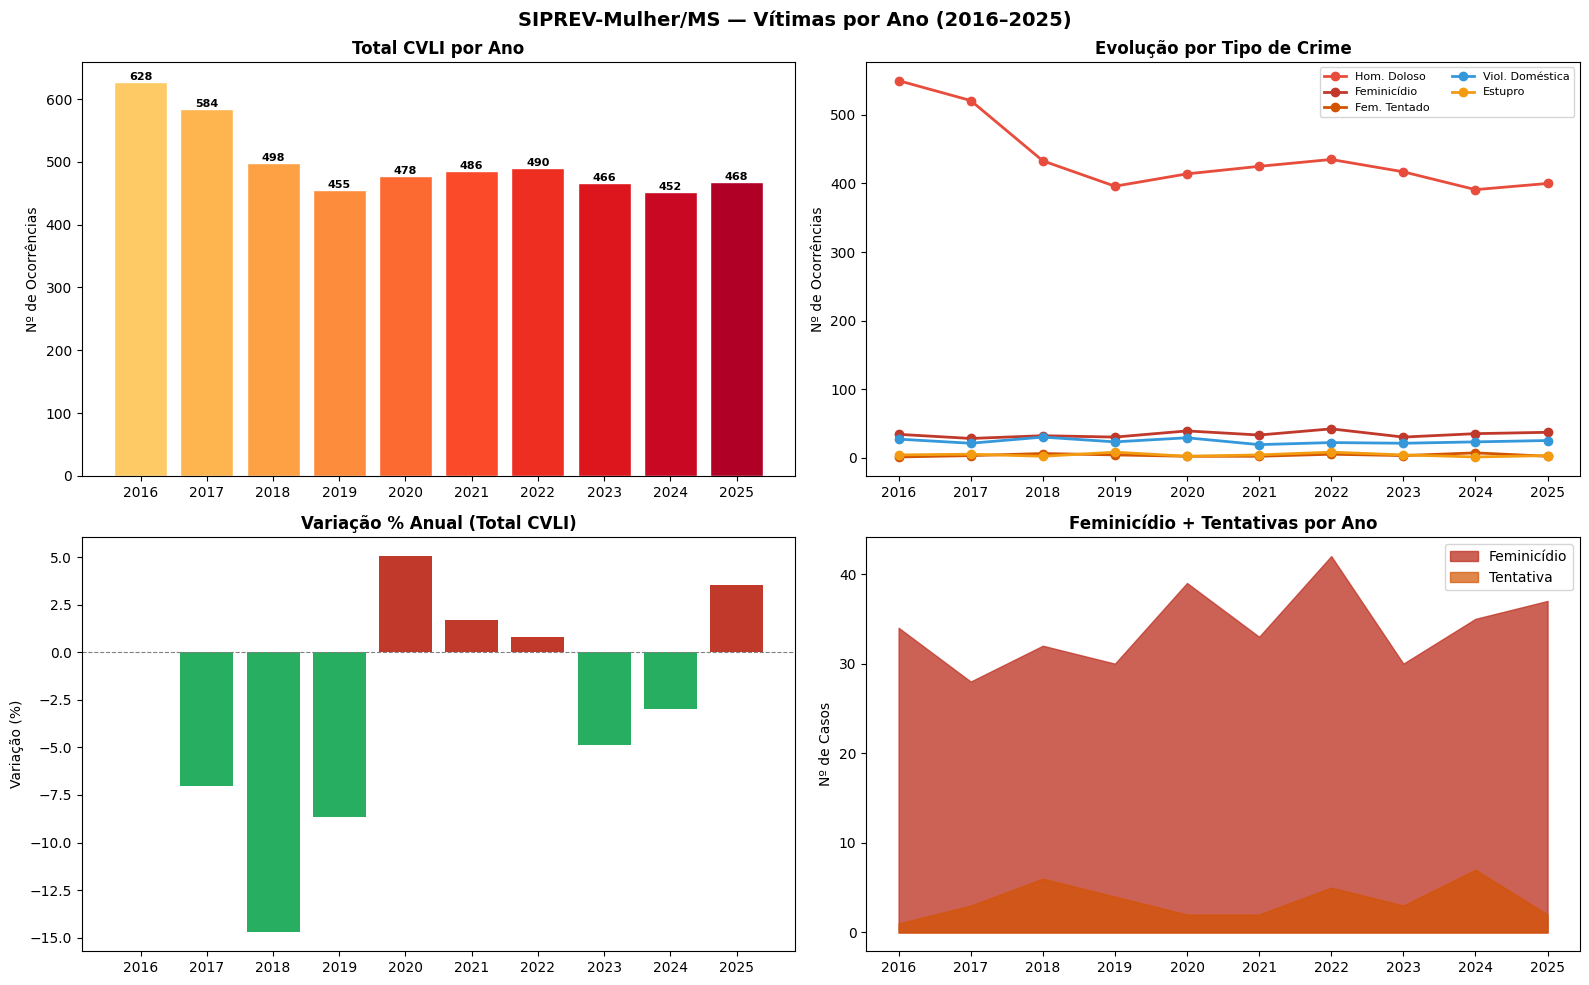

✅ A.5 Gráfico: A2_vitimas_ano.png


In [8]:
# ------------------------------------------------------------------
# A.5  Vítimas por Ano — Gráficos e Tabelas
# ------------------------------------------------------------------
por_ano = (
    df_completo.groupby("ano")
    .agg(
        n_total        = ("id", "count"),
        n_feminicidio  = ("flag_feminicidio", "sum"),
        n_fem_tentada  = ("flag_fem_tentada", "sum"),
        n_hom_doloso   = ("flag_hom_doloso", "sum"),
        n_viol_dom     = ("flag_viol_domestica", "sum"),
        n_estupro      = ("flag_estupro", "sum"),
        n_deam         = ("is_deam", "sum"),
    )
    .reset_index()
)
por_ano["var_pct"] = por_ano["n_total"].pct_change() * 100

por_ano.to_csv(TAB_DIR / "A2_vitimas_ano.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("SIPREV-Mulher/MS — Vítimas por Ano (2016–2025)",
             fontsize=14, fontweight="bold")

cores_tipo = ["#E74C3C","#C0392B","#D35400","#3498DB","#F39C12","#1ABC9C"]
campos = ["n_hom_doloso","n_feminicidio","n_fem_tentada","n_viol_dom","n_estupro"]
labels = ["Hom. Doloso","Feminicídio","Fem. Tentado","Viol. Doméstica","Estupro"]

# (a) Total por ano
axes[0,0].bar(por_ano["ano"].astype(str), por_ano["n_total"],
              color=plt.cm.YlOrRd(np.linspace(0.3,0.9,len(por_ano))), edgecolor="white")
axes[0,0].set_title("Total CVLI por Ano", fontweight="bold")
axes[0,0].set_ylabel("Nº de Ocorrências")
for x, y in zip(por_ano["ano"].astype(str), por_ano["n_total"]):
    axes[0,0].text(x, y+3, str(y), ha="center", fontsize=8, fontweight="bold")

# (b) Linhas por tipo
for campo, label, cor in zip(campos, labels, cores_tipo):
    axes[0,1].plot(por_ano["ano"].astype(str), por_ano[campo],
                   marker="o", linewidth=2, label=label, color=cor)
axes[0,1].set_title("Evolução por Tipo de Crime", fontweight="bold")
axes[0,1].legend(fontsize=8, ncol=2)
axes[0,1].set_ylabel("Nº de Ocorrências")

# (c) Variação percentual anual
cores_var = ["#27AE60" if v < 0 else "#C0392B" for v in por_ano["var_pct"].fillna(0)]
axes[1,0].bar(por_ano["ano"].astype(str), por_ano["var_pct"].fillna(0), color=cores_var)
axes[1,0].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[1,0].set_title("Variação % Anual (Total CVLI)", fontweight="bold")
axes[1,0].set_ylabel("Variação (%)")

# (d) Área empilhada feminicídio + tentado
axes[1,1].fill_between(por_ano["ano"].astype(str), por_ano["n_feminicidio"],
                        alpha=0.8, color="#C0392B", label="Feminicídio")
axes[1,1].fill_between(por_ano["ano"].astype(str), por_ano["n_fem_tentada"],
                        alpha=0.7, color="#D35400", label="Tentativa")
axes[1,1].set_title("Feminicídio + Tentativas por Ano", fontweight="bold")
axes[1,1].legend()
axes[1,1].set_ylabel("Nº de Casos")

plt.tight_layout()
plt.savefig(GRF_DIR / "A2_vitimas_ano.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ A.5 Gráfico: A2_vitimas_ano.png")


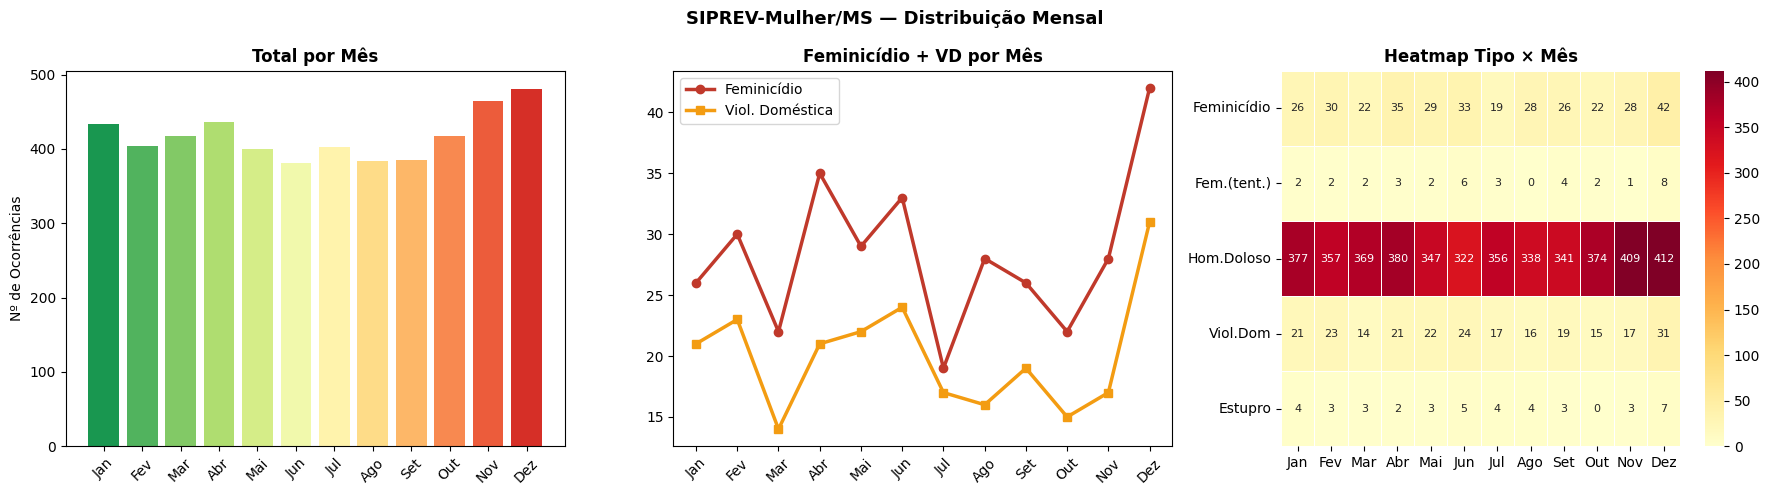

✅ A.6 Gráfico: A3_vitimas_mes.png


In [9]:
# ------------------------------------------------------------------
# A.6  Vítimas por Mês — Gráficos e Tabelas
# ------------------------------------------------------------------
MESES_PT = {1:"Jan",2:"Fev",3:"Mar",4:"Abr",5:"Mai",6:"Jun",
            7:"Jul",8:"Ago",9:"Set",10:"Out",11:"Nov",12:"Dez"}

por_mes = df_completo.groupby("mes").agg(
    n_total=("id","count"),
    n_feminicidio=("flag_feminicidio","sum"),
    n_viol_dom=("flag_viol_domestica","sum"),
    n_fim_semana=("fim_semana","sum"),
).reset_index()
por_mes["mes_nome"] = por_mes["mes"].map(MESES_PT)
por_mes["prop_fds"] = (por_mes["n_fim_semana"] / por_mes["n_total"] * 100).round(1)
por_mes.to_csv(TAB_DIR / "A3_vitimas_mes.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SIPREV-Mulher/MS — Distribuição Mensal", fontsize=13, fontweight="bold")

paleta_m = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 12))
axes[0].bar(por_mes["mes_nome"], por_mes["n_total"], color=paleta_m)
axes[0].set_title("Total por Mês", fontweight="bold")
axes[0].set_ylabel("Nº de Ocorrências")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(por_mes["mes_nome"], por_mes["n_feminicidio"],
             marker="o", color="#C0392B", linewidth=2.5, label="Feminicídio")
axes[1].plot(por_mes["mes_nome"], por_mes["n_viol_dom"],
             marker="s", color="#F39C12", linewidth=2.5, label="Viol. Doméstica")
axes[1].set_title("Feminicídio + VD por Mês", fontweight="bold")
axes[1].legend(); axes[1].tick_params(axis="x", rotation=45)

# Heatmap: tipo × mês
tipos_flags = {
    "Feminicídio":"flag_feminicidio", "Fem.(tent.)":"flag_fem_tentada",
    "Hom.Doloso":"flag_hom_doloso",   "Viol.Dom":"flag_viol_domestica",
    "Estupro":"flag_estupro",
}
hm = pd.DataFrame({
    label: df_completo.groupby("mes")[flag].sum()
    for label, flag in tipos_flags.items()
}).T
hm.columns = [MESES_PT[c] for c in hm.columns]
sns.heatmap(hm, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[2],
            linewidths=0.4, annot_kws={"size":8})
axes[2].set_title("Heatmap Tipo × Mês", fontweight="bold")

plt.tight_layout()
plt.savefig(GRF_DIR / "A3_vitimas_mes.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ A.6 Gráfico: A3_vitimas_mes.png")


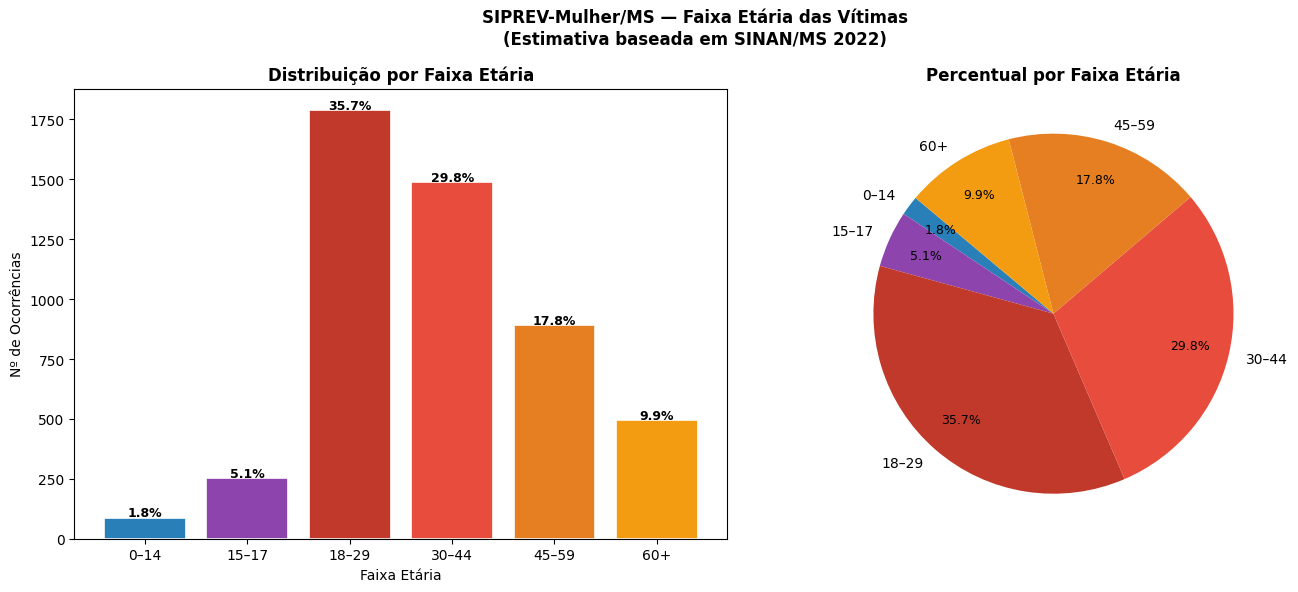

✅ A.7 Gráfico: A4_faixa_etaria_vitima.png


In [10]:
# ------------------------------------------------------------------
# A.7  Faixa Etária das Vítimas — Gráficos e Tabelas
# ------------------------------------------------------------------
# Nota: estimativa baseada em distribuição SINAN/MS 2022 (campo não existe no CVLI)
por_faixa = df_completo.groupby("faixa_etaria_vitima").size().reset_index(name="n")
por_faixa["pct"] = (por_faixa["n"] / por_faixa["n"].sum() * 100).round(1)
por_faixa.to_csv(TAB_DIR / "A4_faixa_etaria_vitima.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("SIPREV-Mulher/MS — Faixa Etária das Vítimas\n(Estimativa baseada em SINAN/MS 2022)",
             fontsize=12, fontweight="bold")

ordem_faixas = ["0–14","15–17","18–29","30–44","45–59","60+"]
por_faixa_ord = por_faixa.set_index("faixa_etaria_vitima").reindex(ordem_faixas).reset_index()

paleta_f = ["#2980B9","#8E44AD","#C0392B","#E74C3C","#E67E22","#F39C12"]
axes[0].bar(por_faixa_ord["faixa_etaria_vitima"], por_faixa_ord["n"],
            color=paleta_f, edgecolor="white", linewidth=1.2)
for x, y, p in zip(por_faixa_ord["faixa_etaria_vitima"],
                    por_faixa_ord["n"], por_faixa_ord["pct"]):
    axes[0].text(x, y + 5, f"{p:.1f}%", ha="center", fontsize=9, fontweight="bold")
axes[0].set_title("Distribuição por Faixa Etária", fontweight="bold")
axes[0].set_ylabel("Nº de Ocorrências")
axes[0].set_xlabel("Faixa Etária")

wedges, _, autotexts = axes[1].pie(
    por_faixa_ord["n"].fillna(0),
    labels=por_faixa_ord["faixa_etaria_vitima"],
    autopct="%1.1f%%", colors=paleta_f,
    startangle=140, pctdistance=0.78
)
for at in autotexts: at.set_fontsize(9)
axes[1].set_title("Percentual por Faixa Etária", fontweight="bold")

plt.tight_layout()
plt.savefig(GRF_DIR / "A4_faixa_etaria_vitima.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ A.7 Gráfico: A4_faixa_etaria_vitima.png")


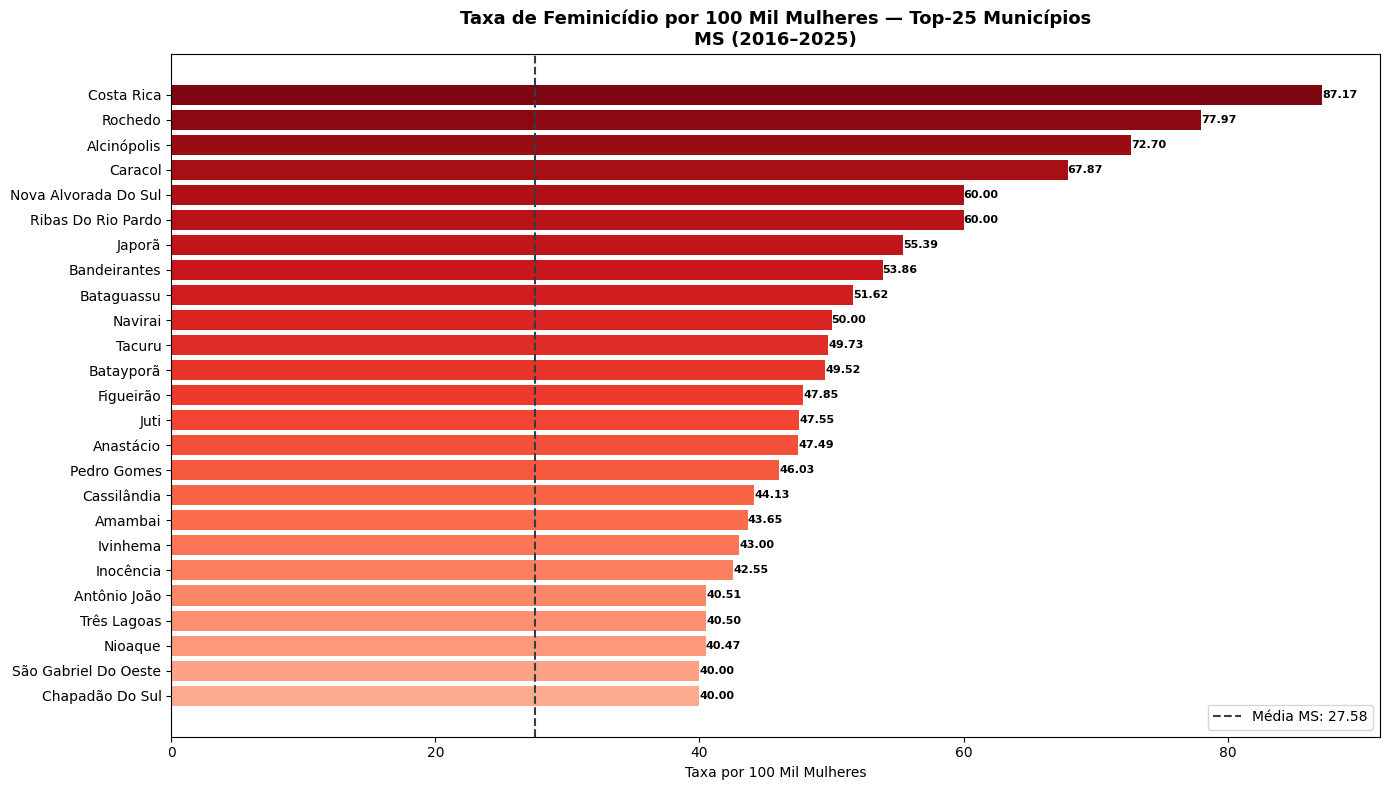

✅ A.8 Taxa por 100k salva


In [11]:
# ------------------------------------------------------------------
# A.8  Taxa de Vítimas por 100 Mil Mulheres — Mapa, Tabela, Gráfico
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))
top_taxa = tab_base.sort_values("taxa_fem_100k", ascending=False).head(25)
cores_taxa = plt.cm.Reds(np.linspace(0.3, 0.95, len(top_taxa)))
bars = ax.barh(top_taxa["nm_municipio"][::-1], top_taxa["taxa_fem_100k"][::-1],
               color=cores_taxa)
for bar, v in zip(bars, top_taxa["taxa_fem_100k"][::-1]):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
            f"{v:.2f}", va="center", fontsize=8, fontweight="bold")
ax.axvline(tab_base["taxa_fem_100k"].mean(), color="#2C3E50", linestyle="--",
           linewidth=1.5, label=f"Média MS: {tab_base['taxa_fem_100k'].mean():.2f}")
ax.set_title("Taxa de Feminicídio por 100 Mil Mulheres — Top-25 Municípios\nMS (2016–2025)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Taxa por 100 Mil Mulheres")
ax.legend()
plt.tight_layout()
plt.savefig(GRF_DIR / "A5_taxa_fem_100k.png", bbox_inches="tight", dpi=120)
plt.show()

tab_base[["nm_municipio","n_feminicidio","pop_mulheres","taxa_fem_100k",
          "ranking","vs_media_str","classe_risco"]].to_csv(
    TAB_DIR / "A5_taxa_fem_100k.csv", index=False, encoding="utf-8-sig")
print("✅ A.8 Taxa por 100k salva")


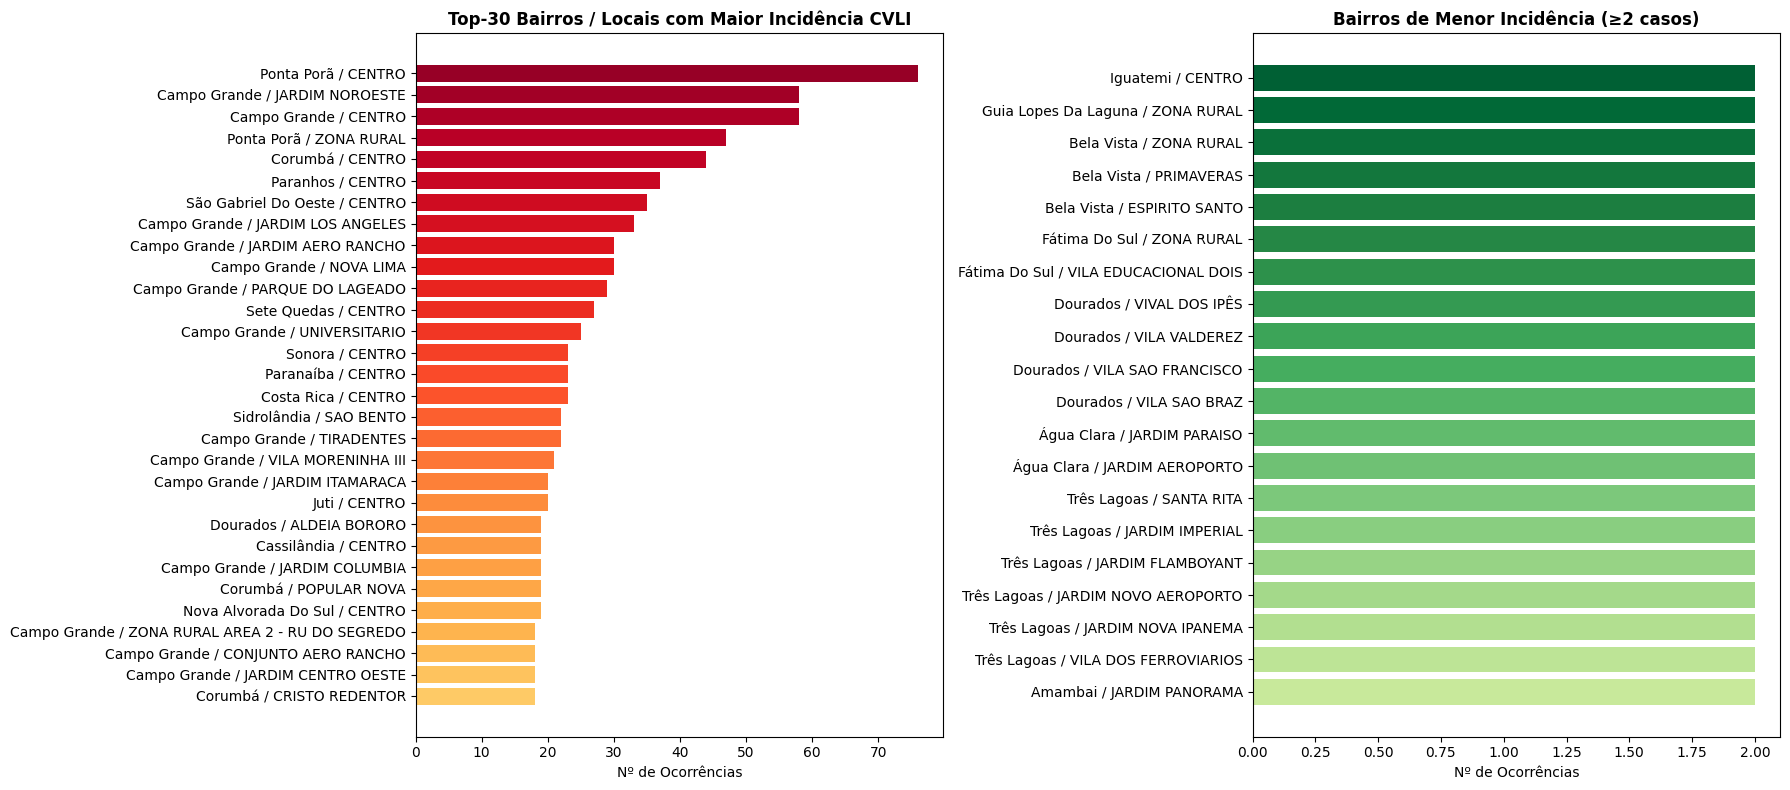

✅ A.9 Bairros salvo


In [12]:
# ------------------------------------------------------------------
# A.9  Locais de Maior Incidência — Bairros (Gráfico + Tabela)
# ------------------------------------------------------------------
top_bairros = (
    df_completo[df_completo["bairro"].notna() & (df_completo["bairro"] != "nan")]
    .groupby(["nm_municipio","bairro"])
    .agg(n=("id","count"), n_fem=("flag_feminicidio","sum"))
    .reset_index()
    .sort_values("n", ascending=False)
)
top_bairros["local"] = top_bairros["nm_municipio"] + " / " + top_bairros["bairro"]
top_bairros.to_csv(TAB_DIR / "A6_bairros_incidencia.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
t30 = top_bairros.head(30)
cores_b = plt.cm.YlOrRd(np.linspace(0.3,0.95,30))
axes[0].barh(t30["local"][::-1], t30["n"][::-1], color=cores_b)
axes[0].set_title("Top-30 Bairros / Locais com Maior Incidência CVLI",
                  fontweight="bold")
axes[0].set_xlabel("Nº de Ocorrências")

# Menor incidência
menor = top_bairros[top_bairros["n"]>=2].tail(20)
axes[1].barh(menor["local"][::-1], menor["n"][::-1],
             color=plt.cm.YlGn(np.linspace(0.3,0.9,len(menor))))
axes[1].set_title("Bairros de Menor Incidência (≥2 casos)", fontweight="bold")
axes[1].set_xlabel("Nº de Ocorrências")

plt.tight_layout()
plt.savefig(GRF_DIR / "A6_bairros.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ A.9 Bairros salvo")


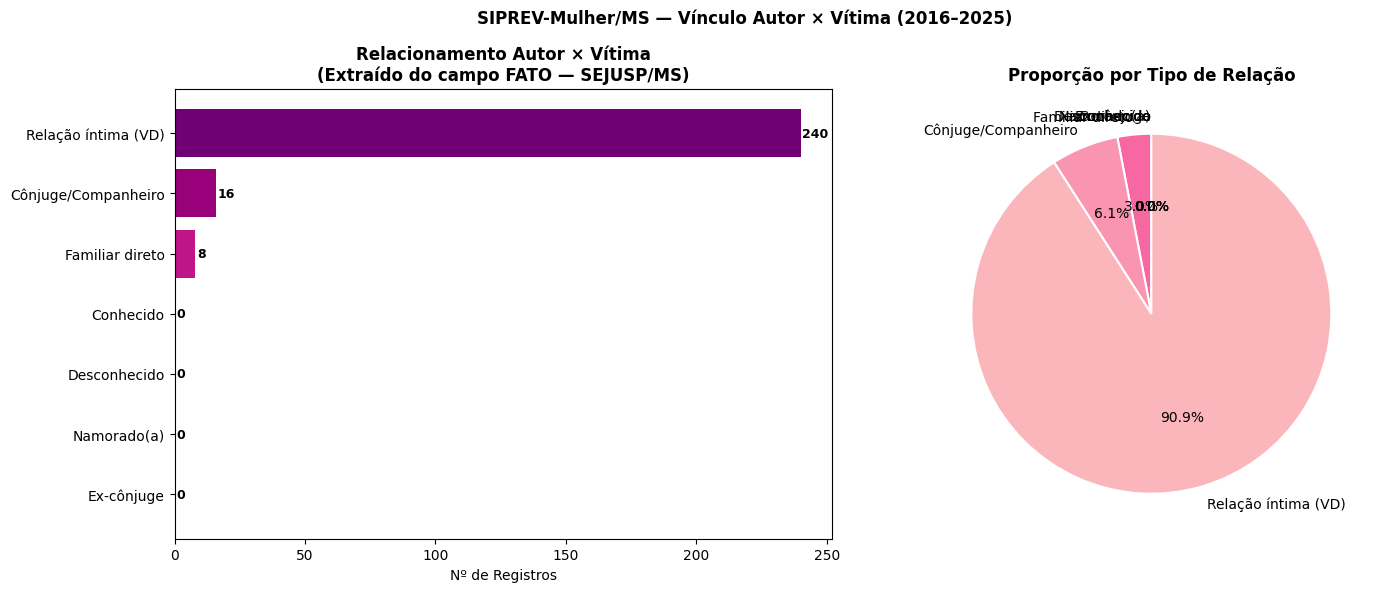

✅ A.10 Relacionamentos salvo


In [13]:
# ------------------------------------------------------------------
# A.10  Relacionamentos Autor × Vítima (Grau de Parentesco)
# ------------------------------------------------------------------
REL_COLS = {
    "Cônjuge/Companheiro":  "rel_cônjuge/companheiro",
    "Ex-cônjuge":           "rel_ex-cônjuge",
    "Namorado(a)":          "rel_namorado(a)",
    "Familiar direto":      "rel_familiar_direto",
    "Conhecido":            "rel_conhecido",
    "Desconhecido":         "rel_desconhecido",
    "Própria vítima":       "rel_própria_vítima",
}

rel_totais = {}
for label, col_raw in REL_COLS.items():
    # Busca coluna com nome normalizado
    col = next((c for c in df_completo.columns if "rel_" in c and
                any(k in c for k in label.lower().split("/")[:1])), None)
    if col and col in df_completo.columns:
        rel_totais[label] = int(df_completo[col].sum())

# Complementa com extração direta do campo FATO
fato_up = df_completo["fato"].str.upper().fillna("")
rel_direto = {
    "Cônjuge/Companheiro":  fato_up.str.contains(r"CONJUGE|COMPANHEIRO|COMPANHEIRA", regex=True).sum(),
    "Ex-cônjuge":          fato_up.str.contains(r"EX-CONJUGE|EX-COMPANHEIRO|EX-MARIDO", regex=True).sum(),
    "Namorado(a)":         fato_up.str.contains(r"NAMORAD", regex=True).sum(),
    "Familiar direto":     fato_up.str.contains(r"FILHO|MAE\b|PAI\b|IRMAO|IRMA\b", regex=True).sum(),
    "Conhecido":           fato_up.str.contains(r"CONHECIDO|VIZINHO", regex=True).sum(),
    "Desconhecido":        fato_up.str.contains(r"DESCONHECIDO", regex=True).sum(),
    "Relação íntima (VD)": int(df_completo["flag_viol_domestica"].sum()),
}
rel_ser = pd.Series(rel_direto).sort_values(ascending=True)
rel_df = rel_ser.reset_index()
rel_df.columns = ["Relacionamento", "N"]
rel_df.to_csv(TAB_DIR / "A7_relacionamentos.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
paleta_r = plt.cm.RdPu(np.linspace(0.3,0.9,len(rel_ser)))
axes[0].barh(rel_ser.index, rel_ser.values, color=paleta_r)
for i, v in enumerate(rel_ser.values):
    axes[0].text(v+0.5, i, f"{v:,}", va="center", fontsize=9, fontweight="bold")
axes[0].set_title("Relacionamento Autor × Vítima\n(Extraído do campo FATO — SEJUSP/MS)",
                  fontweight="bold")
axes[0].set_xlabel("Nº de Registros")

axes[1].pie(rel_ser.values, labels=rel_ser.index, autopct="%1.1f%%",
            colors=paleta_r[::-1], startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Proporção por Tipo de Relação", fontweight="bold")

plt.suptitle("SIPREV-Mulher/MS — Vínculo Autor × Vítima (2016–2025)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(GRF_DIR / "A7_relacionamentos.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ A.10 Relacionamentos salvo")


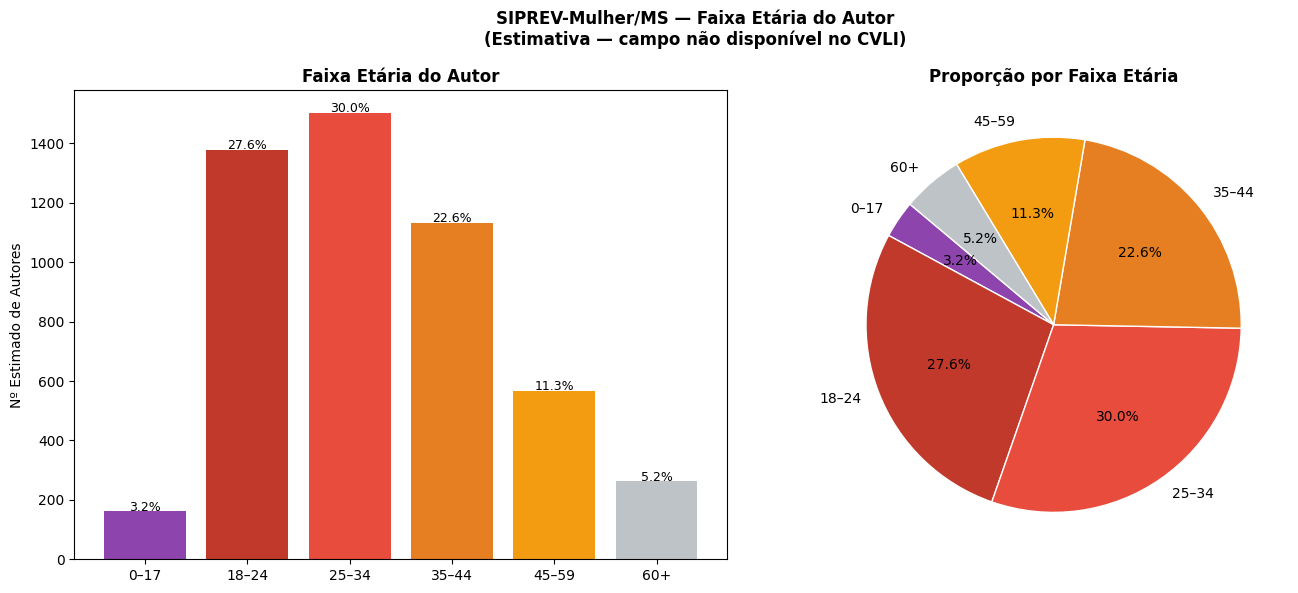

✅ A.11 Faixa etária do autor salva


In [14]:
# ------------------------------------------------------------------
# A.11  Autor por Faixa Etária — Gráficos e Tabelas
# ------------------------------------------------------------------
por_faixa_autor = df_completo.groupby("faixa_etaria_autor").size().reset_index(name="n")
por_faixa_autor["pct"] = (por_faixa_autor["n"] / por_faixa_autor["n"].sum() * 100).round(1)
por_faixa_autor.to_csv(TAB_DIR / "A8_faixa_etaria_autor.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("SIPREV-Mulher/MS — Faixa Etária do Autor\n(Estimativa — campo não disponível no CVLI)",
             fontsize=12, fontweight="bold")

ordem_a = ["0–17","18–24","25–34","35–44","45–59","60+"]
fa_ord = por_faixa_autor.set_index("faixa_etaria_autor").reindex(ordem_a).reset_index()
paleta_a = ["#8E44AD","#C0392B","#E74C3C","#E67E22","#F39C12","#BDC3C7"]
axes[0].bar(fa_ord["faixa_etaria_autor"], fa_ord["n"].fillna(0), color=paleta_a)
for x, y, p in zip(fa_ord["faixa_etaria_autor"],
                    fa_ord["n"].fillna(0), fa_ord["pct"].fillna(0)):
    axes[0].text(x, y+3, f"{p:.1f}%", ha="center", fontsize=9)
axes[0].set_title("Faixa Etária do Autor", fontweight="bold")
axes[0].set_ylabel("Nº Estimado de Autores")

axes[1].pie(fa_ord["n"].fillna(0), labels=fa_ord["faixa_etaria_autor"],
            autopct="%1.1f%%", colors=paleta_a,
            startangle=140, wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Proporção por Faixa Etária", fontweight="bold")

plt.tight_layout()
plt.savefig(GRF_DIR / "A8_faixa_etaria_autor.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ A.11 Faixa etária do autor salva")


In [33]:
# Instalação da versão estável do kaleido para exportação de imagem
!pip install kaleido==0.2.1 -q

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ------------------------------------------------------------------
# A.12  Distribuição geral das vítimas (painel síntese)
# ------------------------------------------------------------------
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        "Por Ano", "Por Mês", "Por Turno",
        "Por Tipo de Crime", "Taxa/100k (Top-20)", "Feminicídio x Ano"
    ],
    specs=[[{"type":"bar"},{"type":"bar"},{"type":"pie"}],
           [{"type":"bar"},{"type":"bar"},{"type":"scatter"}]]
)

# Por Ano
fig.add_trace(go.Bar(x=por_ano["ano"].astype(str), y=por_ano["n_total"],
                     marker_color="#E74C3C", name="Total"), row=1, col=1)
# Por Mês
fig.add_trace(go.Bar(x=por_mes["mes_nome"], y=por_mes["n_total"],
                     marker_color="#3498DB", name="Mensal"), row=1, col=2)
# Por Turno
turnos_c = df_completo["turno"].value_counts()
fig.add_trace(go.Pie(labels=turnos_c.index, values=turnos_c.values,
                     name="Turno"), row=1, col=3)
# Por Tipo
tc = df_completo["tipo_crime"].value_counts()
fig.add_trace(go.Bar(x=tc.values, y=tc.index, orientation="h",
                     marker_color="#9B59B6", name="Tipo"), row=2, col=1)
# Taxa/100k Top-20
t20t = tab_base.head(20)
fig.add_trace(go.Bar(x=t20t["taxa_100k"], y=t20t["nm_municipio"],
                     orientation="h", marker_color="#E67E22",
                     name="Taxa/100k"), row=2, col=2)
# Feminicídio x Ano
fig.add_trace(go.Scatter(x=por_ano["ano"].astype(str), y=por_ano["n_feminicidio"],
                          mode="lines+markers", marker=dict(color="#C0392B", size=8),
                          line=dict(width=2.5), name="Feminicídio"), row=2, col=3)

fig.update_layout(
    title_text="🛡️ SIPREV-Mulher/MS — Painel Síntese de Distribuição das Vítimas",
    height=750, showlegend=False,
    paper_bgcolor="#0F1117", plot_bgcolor="rgba(20,20,30,0.8)",
    font=dict(color="white"), title_font=dict(color="white", size=14)
)

# Exportação
fig.write_html(str(OUTPUT_DIR / "A_painel_sintese.html"))
try:
    # O uso do motor 'kaleido' é explícito para evitar conflitos de versão
    fig.write_image(str(GRF_DIR / "A9_painel_sintese.png"), width=1400, height=750, engine="kaleido")
    print("✅ A.12 Painel síntese salvo (HTML + PNG)")
except Exception as e:
    print(f"❌ Erro persistente ao salvar PNG: {e}")
    print("⚠️ Tentando exportação alternativa via engine='auto'...")
    try:
        fig.write_image(str(GRF_DIR / "A9_painel_sintese.png"), width=1400, height=750)
        print("✅ A.12 Painel síntese salvo em PNG (via engine auto)")
    except:
        print("⚠️ PNG não pôde ser gerado; HTML disponível em outputs/A_painel_sintese.html")

❌ Erro persistente ao salvar PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

⚠️ Tentando exportação alternativa via engine='auto'...
⚠️ PNG não pôde ser gerado; HTML disponível em outputs/A_painel_sintese.html


In [34]:
print("\n" + "="*70)
print("🏆 BLOCO B — RANKING MUNICIPAL COMPLETO")
print("="*70)

# ------------------------------------------------------------------
# B.1  Tabela completa de ranking
# ------------------------------------------------------------------
# Adiciona anos de referência
tab_rank_ano = {}
for ano in ANOS_COMPLETOS:
    tab_rank_ano[str(ano)] = (
        df_completo[df_completo["ano"] == ano]
        .groupby("nm_municipio").size()
    )

tab_rank = tab_base.copy()
for ano in ANOS_COMPLETOS:
    tab_rank[f"n_{ano}"] = (
        tab_rank["nm_municipio"].map(tab_rank_ano.get(str(ano), pd.Series(dtype=int)))
        .fillna(0).astype(int)
    )

tab_rank = tab_rank.sort_values("n_total", ascending=False).reset_index(drop=True)
tab_rank["ranking"] = range(1, len(tab_rank) + 1)

tab_rank.to_csv(TAB_DIR / "B1_ranking_municipal_completo.csv", index=False, encoding="utf-8-sig")



🏆 BLOCO B — RANKING MUNICIPAL COMPLETO


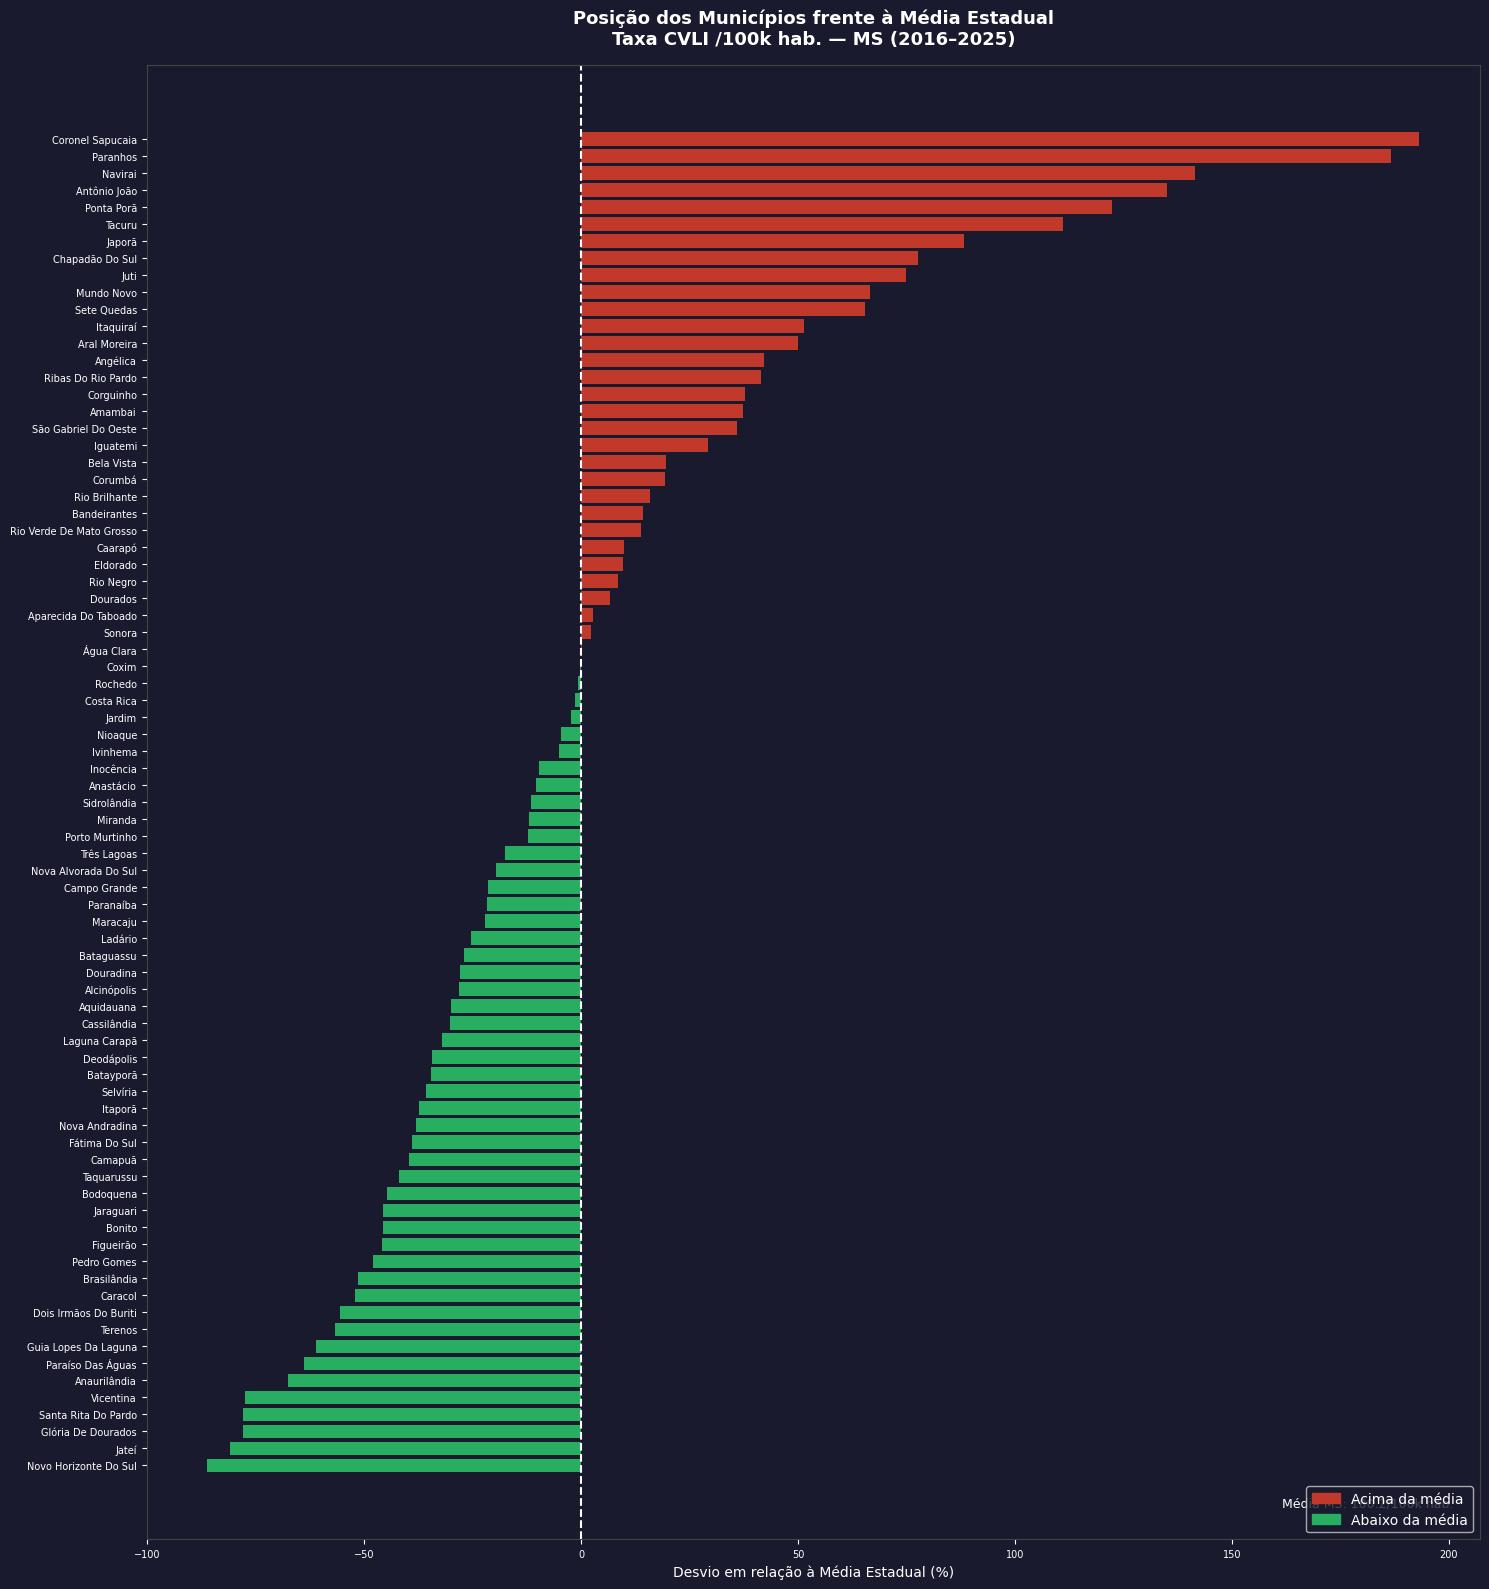

✅ B.2 Posição vs Média salvo


In [35]:
# ------------------------------------------------------------------
# B.2  Posição das Cidades frente à Média Estadual (gráfico)
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 16))
fig.patch.set_facecolor("#1A1A2E")
ax.set_facecolor("#1A1A2E")

rank_plot = tab_rank.sort_values("taxa_100k")
cores_vm = ["#C0392B" if v > 0 else "#27AE60" for v in rank_plot["vs_media_pct"]]
bars = ax.barh(rank_plot["nm_municipio"], rank_plot["vs_media_pct"], color=cores_vm)
ax.axvline(0, color="white", linewidth=1.5, linestyle="--")
ax.set_title("Posição dos Municípios frente à Média Estadual\nTaxa CVLI /100k hab. — MS (2016–2025)",
             fontsize=13, fontweight="bold", color="white", pad=15)
ax.set_xlabel("Desvio em relação à Média Estadual (%)", color="white")
ax.tick_params(colors="white", labelsize=7)
for spine in ax.spines.values(): spine.set_edgecolor("#444")

legenda_patches = [
    mpatches.Patch(color="#C0392B", label="Acima da média"),
    mpatches.Patch(color="#27AE60", label="Abaixo da média"),
]
ax.legend(handles=legenda_patches, loc="lower right",
          facecolor="#1A1A2E", labelcolor="white")
ax.text(0.98, 0.02, f"Média MS: {media_estadual:.1f}/100k hab.",
        transform=ax.transAxes, color="white", fontsize=9,
        ha="right", va="bottom")

plt.tight_layout()
plt.savefig(GRF_DIR / "B2_posicao_vs_media.png", bbox_inches="tight",
            dpi=120, facecolor="#1A1A2E")
plt.show()
print("✅ B.2 Posição vs Média salvo")



📊 Maior/Menor por Indicador:
          Indicador   Maior — Cidade Maior — Valor        Menor — Cidade Menor — Valor Média MS
         Total CVLI     Campo Grande       1,298.0                 Jateí           2.0     63.4
        Feminicídio     Campo Grande          79.0              Paranhos           0.0      4.3
   Homicídio Doloso     Campo Grande       1,145.0                 Jateí           2.0     55.5
Violência Doméstica     Campo Grande          68.0               Miranda           0.0      3.0
         Taxa /100k Coronel Sapucaia         528.3 Novo Horizonte Do Sul          25.0    180.2
     Taxa Fem /100k       Costa Rica          87.2              Paranhos           0.0     27.6


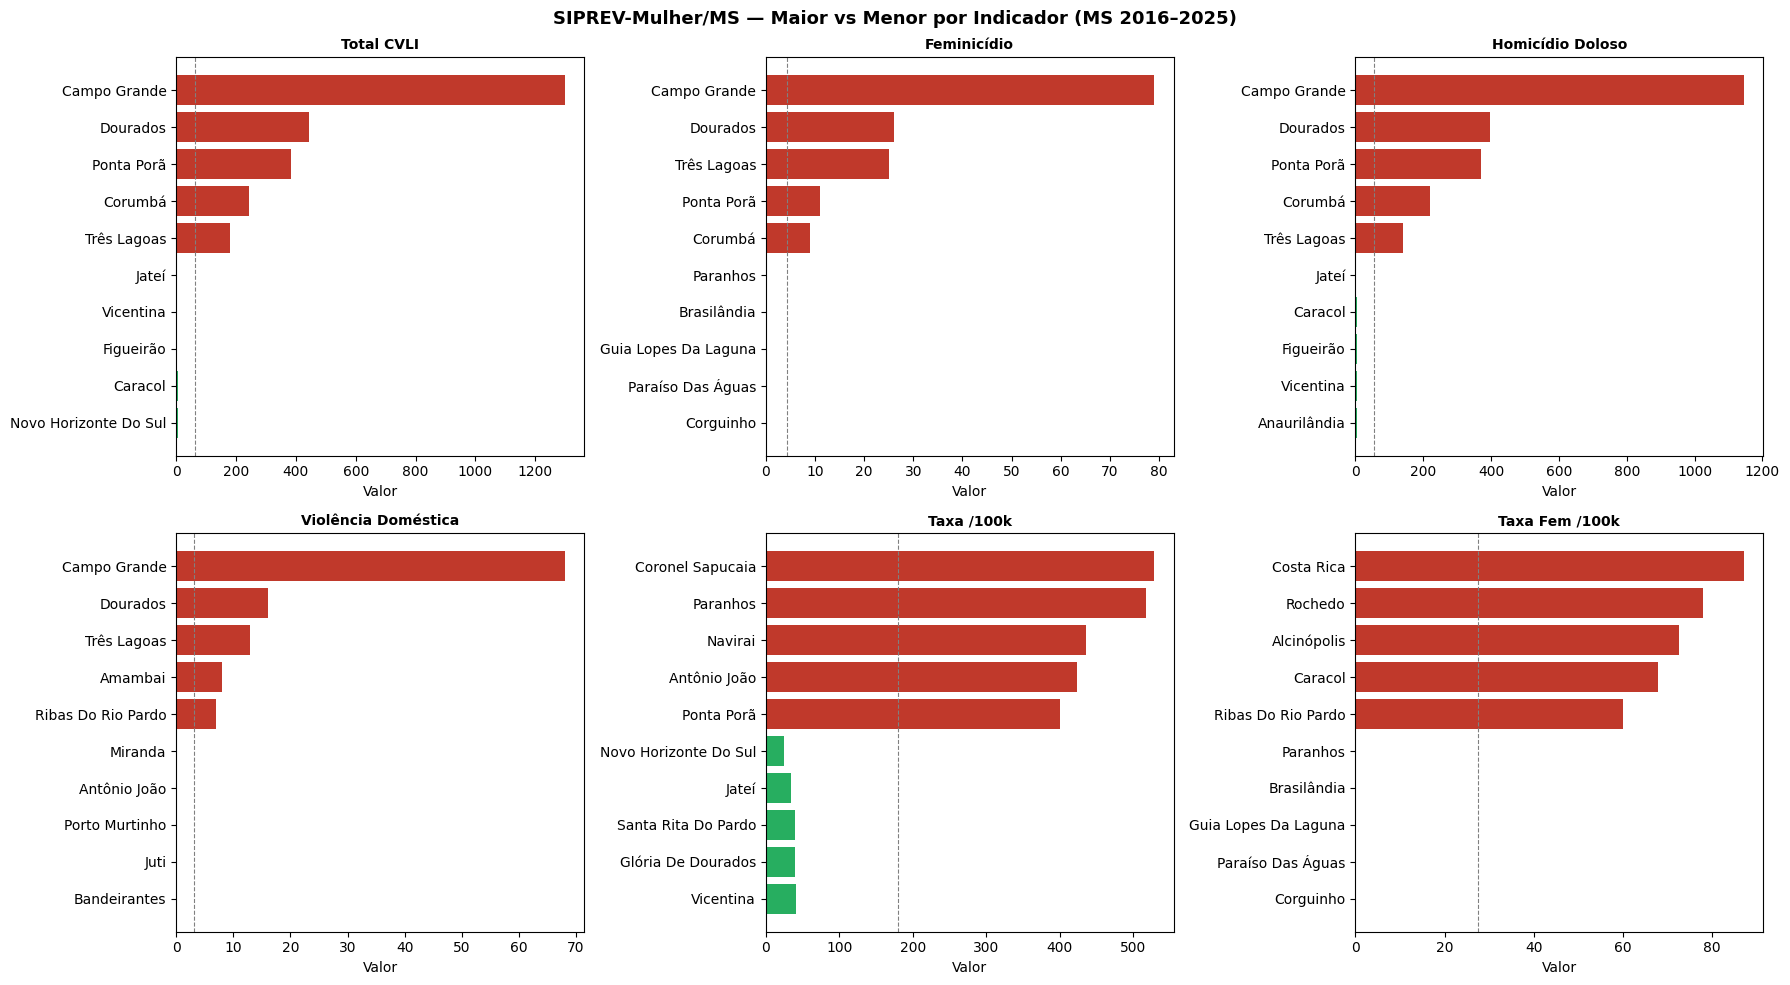

✅ B.3 Indicadores Maior/Menor salvo


In [36]:
# ------------------------------------------------------------------
# B.3  Cidade com Maior / Menor Valor nos Indicadores
# ------------------------------------------------------------------
INDICADORES = {
    "Total CVLI":         "n_total",
    "Feminicídio":        "n_feminicidio",
    "Homicídio Doloso":   "n_hom_doloso",
    "Violência Doméstica":"n_viol_dom",
    "Taxa /100k":         "taxa_100k",
    "Taxa Fem /100k":     "taxa_fem_100k",
}

rows_ind = []
for ind_nome, col in INDICADORES.items():
    if col not in tab_rank.columns:
        continue
    max_row = tab_rank.loc[tab_rank[col].idxmax()]
    min_row = tab_rank.loc[tab_rank[col].idxmin()]
    rows_ind.append({
        "Indicador":        ind_nome,
        "Maior — Cidade":   max_row["nm_municipio"],
        "Maior — Valor":    f"{max_row[col]:,.1f}",
        "Menor — Cidade":   min_row["nm_municipio"],
        "Menor — Valor":    f"{min_row[col]:,.1f}",
        "Média MS":         f"{tab_rank[col].mean():,.1f}",
    })

tab_ind = pd.DataFrame(rows_ind)
tab_ind.to_csv(TAB_DIR / "B3_maior_menor_indicador.csv", index=False, encoding="utf-8-sig")
print("\n📊 Maior/Menor por Indicador:")
print(tab_ind.to_string(index=False))

# Gráfico radar/comparativo
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("SIPREV-Mulher/MS — Maior vs Menor por Indicador (MS 2016–2025)",
             fontsize=13, fontweight="bold")

for ax, (ind_nome, col) in zip(axes.flat, INDICADORES.items()):
    if col not in tab_rank.columns:
        continue
    top5 = tab_rank.nlargest(5, col)[["nm_municipio", col]]
    bottom5 = tab_rank.nsmallest(5, col)[["nm_municipio", col]]
    dados = pd.concat([top5.assign(tipo="Top-5"), bottom5.assign(tipo="Bottom-5")])
    cores_comp = ["#C0392B"]*5 + ["#27AE60"]*5
    ax.barh(dados["nm_municipio"][::-1], dados[col][::-1], color=cores_comp[::-1])
    ax.set_title(ind_nome, fontweight="bold", fontsize=10)
    ax.set_xlabel("Valor")
    ax.axvline(tab_rank[col].mean(), color="gray", linestyle="--",
               linewidth=0.8, label="Média")

plt.tight_layout()
plt.savefig(GRF_DIR / "B3_maior_menor_indicadores.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ B.3 Indicadores Maior/Menor salvo")


In [37]:
# ------------------------------------------------------------------
# B.4  Mapa de Ranking Municipal (todos os 79 municípios)
# ------------------------------------------------------------------
mapa_rank = folium.Map(location=[-20.5,-54.5], zoom_start=6, tiles="CartoDB Positron")
folium.TileLayer("OpenStreetMap").add_to(mapa_rank)
folium.TileLayer("CartoDB dark_matter").add_to(mapa_rank)

COR_RISCO_MAP = {"🔴 Alto":"#C0392B","🟡 Médio":"#F39C12","🟢 Baixo":"#27AE60"}

for _, row in tab_rank.iterrows():
    lat = CENTROIDES_MS.get(row["nm_municipio"], (-20.5,-54.5))[0]
    lon = CENTROIDES_MS.get(row["nm_municipio"], (-20.5,-54.5))[1]
    cor = COR_RISCO_MAP.get(row["classe_risco"], "#95A5A6")
    raio = max(5, (row["n_total"] / tab_rank["n_total"].max()) ** 0.5 * 38)

    popup_html = f"""
    <div style='font-family:Arial;min-width:220px;font-size:12px'>
      <b>#{int(row['ranking'])} {row['nm_municipio']}</b><br>
      <hr style='margin:4px 0'>
      🔢 Total CVLI: <b>{int(row['n_total'])}</b> ({row['pct_total']:.2f}%)<br>
      🔴 Feminicídio: <b>{int(row['n_feminicidio'])}</b><br>
      ♻️ Tentativa Fem.: <b>{int(row['n_fem_tentada'])}</b><br>
      💀 Hom. Doloso: <b>{int(row['n_hom_doloso'])}</b><br>
      🏠 Viol. Doméstica: <b>{int(row['n_viol_dom'])}</b><br>
      📈 Taxa/100k: <b>{row['taxa_100k']:.1f}</b><br>
      📊 Fem./100k mulheres: <b>{row['taxa_fem_100k']:.2f}</b><br>
      📍 vs Média MS: <b>{row['vs_media_str']}</b><br>
      ⚠️ Risco: <b style='color:{cor}'>{row['classe_risco']}</b>
    </div>"""

    folium.CircleMarker(
        location=[lat, lon], radius=raio,
        color=cor, fill=True, fill_color=cor, fill_opacity=0.8,
        popup=folium.Popup(popup_html, max_width=270),
        tooltip=f"#{int(row['ranking'])} {row['nm_municipio']} — {row['classe_risco']}",
    ).add_to(mapa_rank)

folium.LayerControl().add_to(mapa_rank)
legenda_rank = f"""<div style="position:fixed;bottom:30px;left:30px;width:220px;
    background:white;padding:12px;border-radius:8px;border:2px solid #C0392B;
    font-family:Arial;font-size:12px;z-index:9999">
  <b>🛡️ SIPREV-Mulher/MS</b><br>
  <b>Ranking Municipal — 79 cidades</b><br>
  MS 2016–2025 | SEJUSP/MS<hr style='margin:5px 0'>
  🔴 Alto Risco | 🟡 Médio | 🟢 Baixo<br>
  Tamanho ∝ volume de casos<br>
  <small>Média estadual: {media_estadual:.1f}/100k hab.</small>
</div>"""
mapa_rank.get_root().html.add_child(folium.Element(legenda_rank))
mapa_rank.save(str(MAP_DIR / "B4_ranking_municipal.html"))
print("✅ B.4 Mapa de ranking salvo: B4_ranking_municipal.html")


✅ B.4 Mapa de ranking salvo: B4_ranking_municipal.html


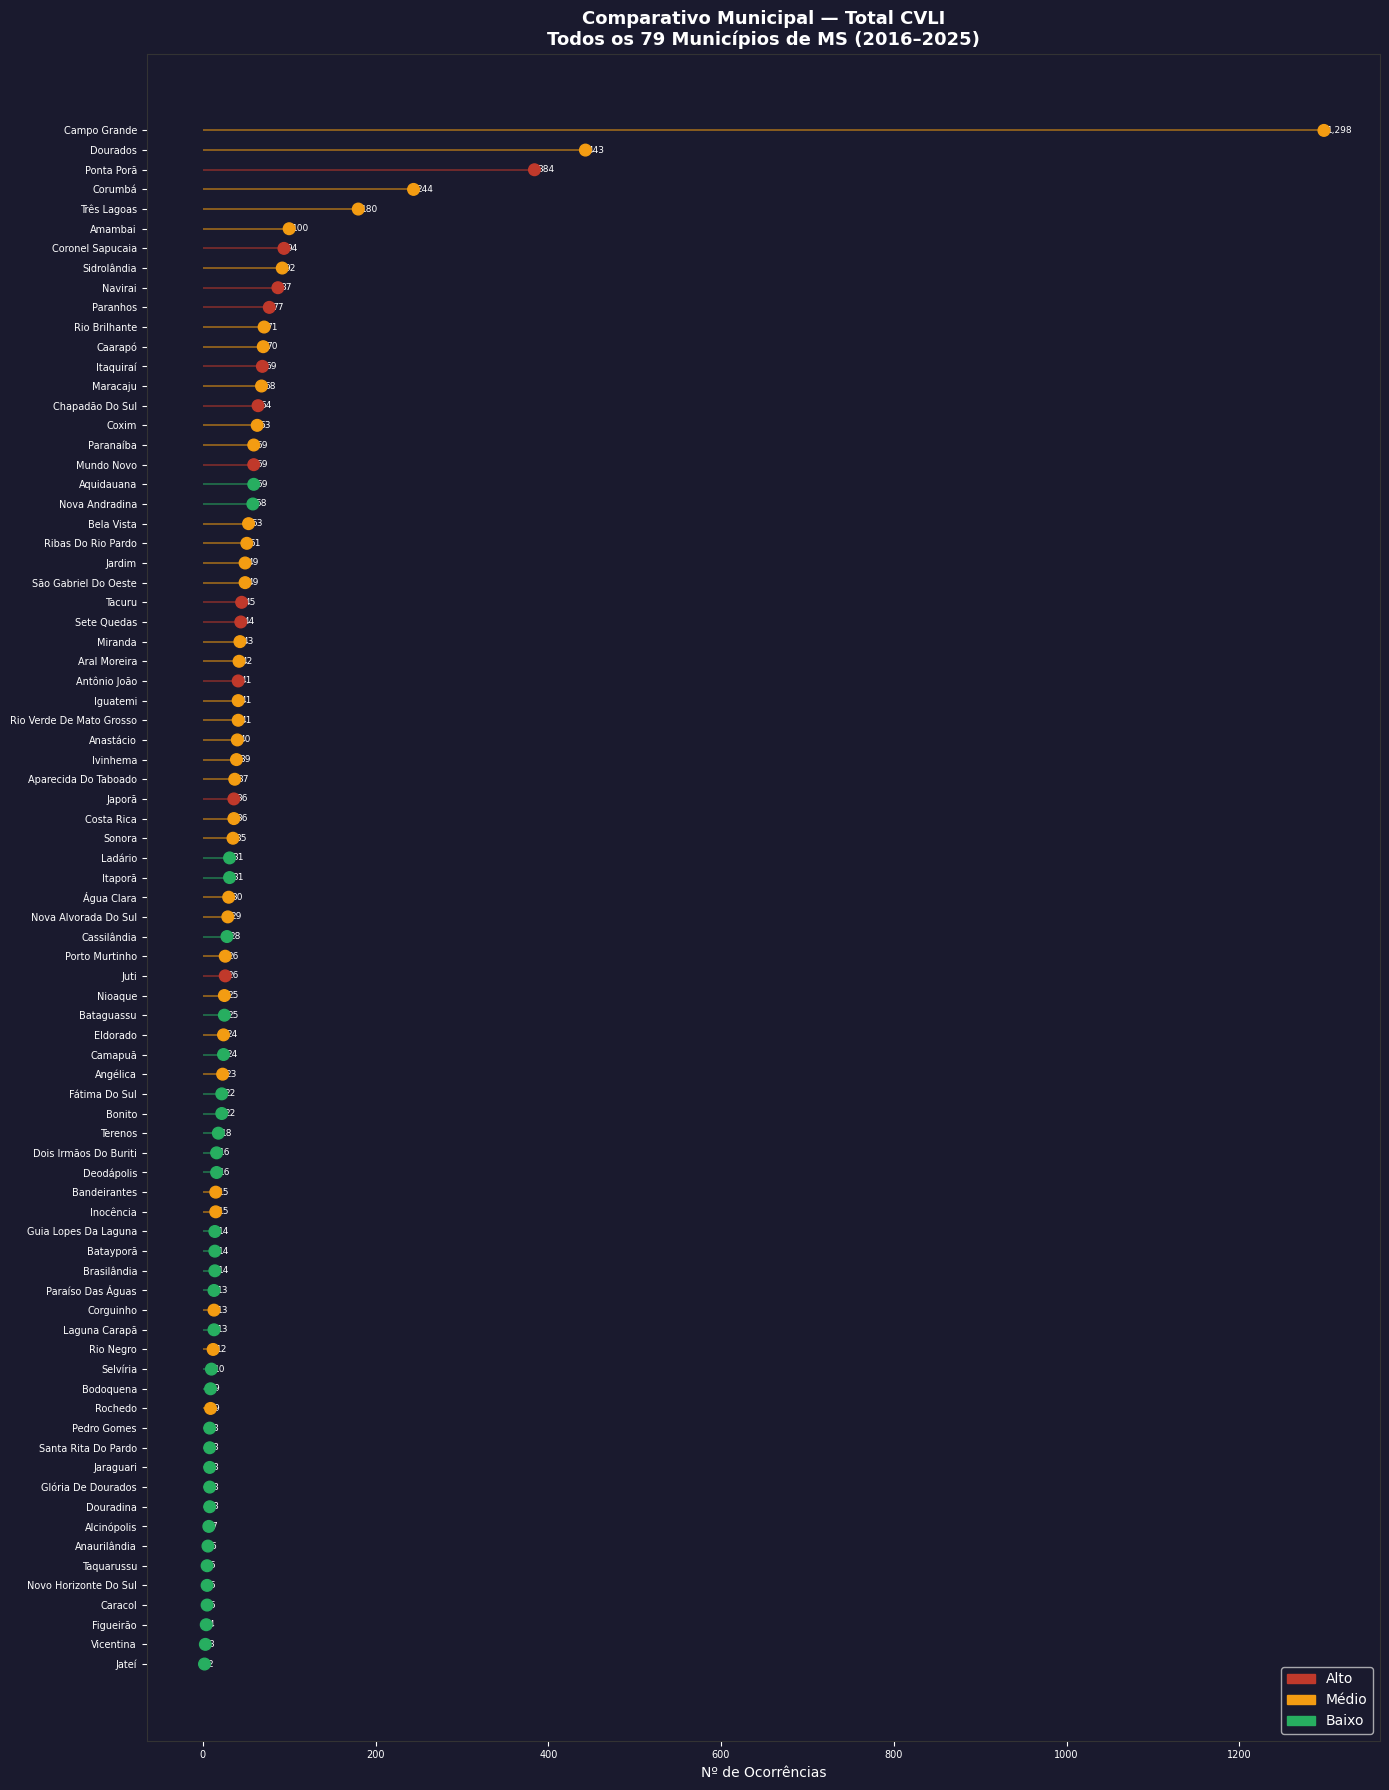

✅ B.5 Comparativo municipal salvo


In [38]:
# ------------------------------------------------------------------
# B.5  Comparativo Municipal — gráfico lollipop + tabela pivot
# ------------------------------------------------------------------
# Gráfico lollipop: todos os municípios x total CVLI
fig, ax = plt.subplots(figsize=(14, 18))
fig.patch.set_facecolor("#1A1A2E")
ax.set_facecolor("#1A1A2E")

rank_plot2 = tab_rank.sort_values("n_total")
cores_risco = [COR_RISCO_MAP.get(r,"#95A5A6") for r in rank_plot2["classe_risco"]]

ax.hlines(rank_plot2["nm_municipio"], 0, rank_plot2["n_total"],
          colors=cores_risco, linewidth=1.2, alpha=0.6)
ax.scatter(rank_plot2["n_total"], rank_plot2["nm_municipio"],
           c=cores_risco, s=70, zorder=5)

for _, row in rank_plot2.iterrows():
    ax.text(row["n_total"]+3, row["nm_municipio"],
            f"{row['n_total']:,}", va="center", fontsize=6.5, color="white")

ax.set_title("Comparativo Municipal — Total CVLI\nTodos os 79 Municípios de MS (2016–2025)",
             fontsize=13, fontweight="bold", color="white")
ax.set_xlabel("Nº de Ocorrências", color="white")
ax.tick_params(colors="white", labelsize=7)
for spine in ax.spines.values(): spine.set_edgecolor("#333")

patches = [mpatches.Patch(color=c, label=r.replace("🔴 ","").replace("🟡 ","").replace("🟢 ",""))
           for r, c in COR_RISCO_MAP.items()]
ax.legend(handles=patches, facecolor="#1A1A2E", labelcolor="white", loc="lower right")

plt.tight_layout()
plt.savefig(GRF_DIR / "B5_comparativo_municipal.png", bbox_inches="tight",
            dpi=120, facecolor="#1A1A2E")
plt.show()
print("✅ B.5 Comparativo municipal salvo")


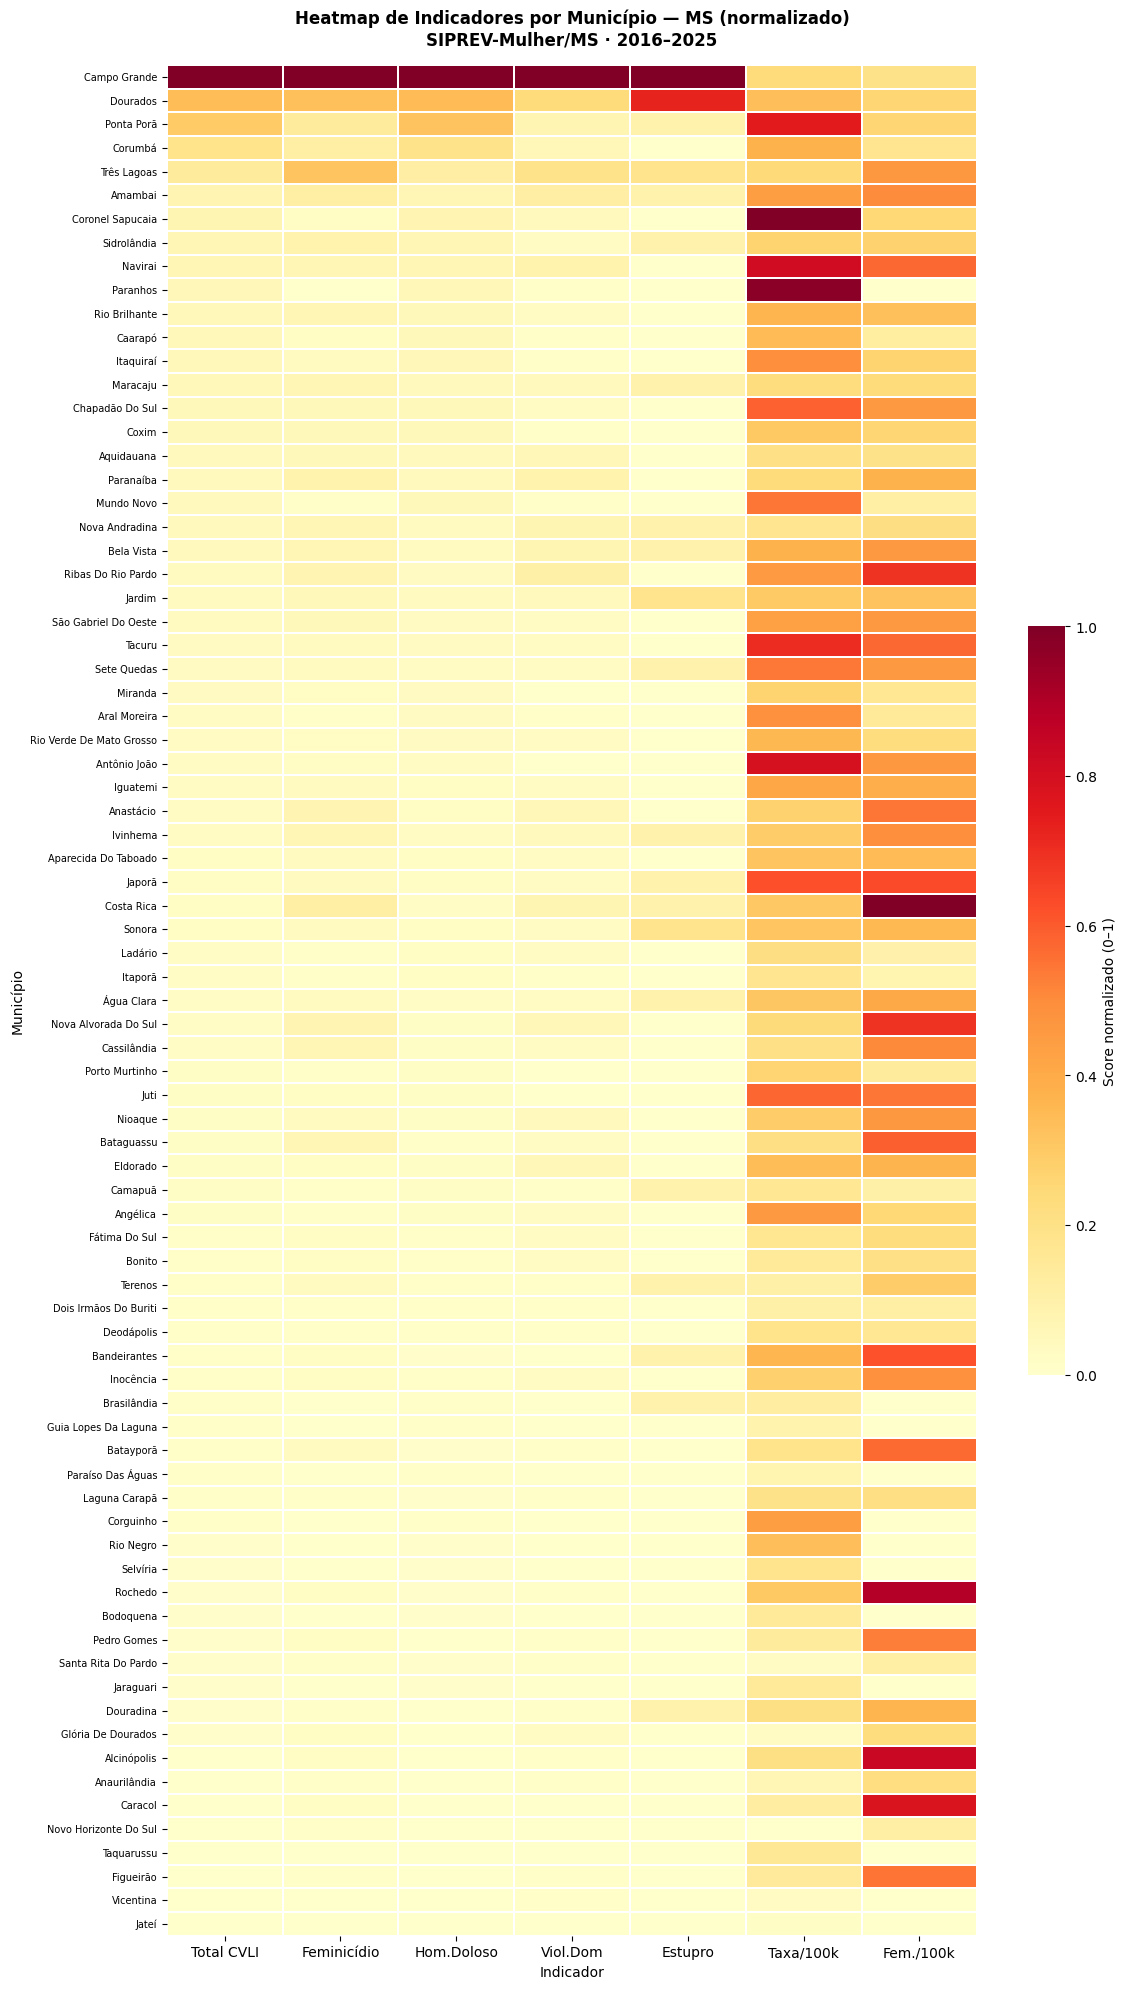

✅ B.6 Heatmap de indicadores por cidade salvo


In [39]:
# ------------------------------------------------------------------
# B.6  Indicadores por Cidade — Gráfico de calor normalizado
# ------------------------------------------------------------------
COLS_IND = ["n_total","n_feminicidio","n_hom_doloso","n_viol_dom",
            "n_estupro","taxa_100k","taxa_fem_100k"]
LABELS_IND = ["Total CVLI","Feminicídio","Hom.Doloso","Viol.Dom",
              "Estupro","Taxa/100k","Fem./100k"]

heat_mun = tab_rank.set_index("nm_municipio")[COLS_IND]
from sklearn.preprocessing import MinMaxScaler
scaler_h = MinMaxScaler()
heat_norm = pd.DataFrame(
    scaler_h.fit_transform(heat_mun.fillna(0)),
    index=heat_mun.index, columns=LABELS_IND
)

fig, ax = plt.subplots(figsize=(12, 20))
sns.heatmap(heat_norm, annot=False, cmap="YlOrRd", ax=ax,
            linewidths=0.2, cbar_kws={"shrink":0.4, "label":"Score normalizado (0–1)"})
ax.set_title("Heatmap de Indicadores por Município — MS (normalizado)\nSIPREV-Mulher/MS · 2016–2025",
             fontsize=12, fontweight="bold", pad=15)
ax.set_xlabel("Indicador")
ax.set_ylabel("Município")
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.savefig(GRF_DIR / "B6_indicadores_cidade.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ B.6 Heatmap de indicadores por cidade salvo")


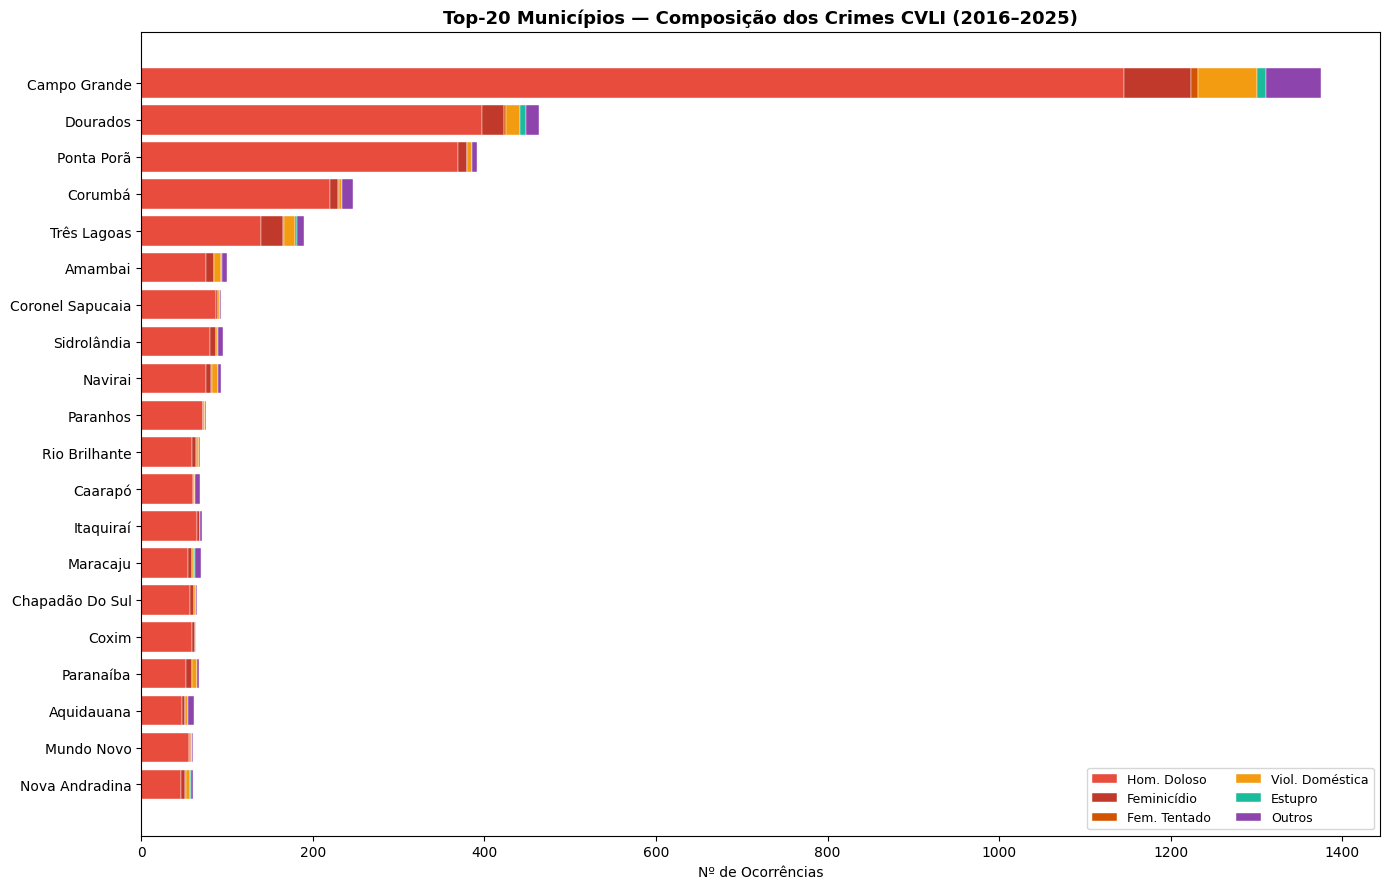

✅ B.7 Ranking de indicadores (barras empilhadas) salvo


In [40]:
# ------------------------------------------------------------------
# B.7  Gráfico de Barras Empilhadas — Ranking de Indicadores
# ------------------------------------------------------------------
top20_rank = tab_rank.head(20).copy()
top20_rank_sorted = top20_rank.sort_values("n_total", ascending=True)

fig, ax = plt.subplots(figsize=(14, 9))
bottom = np.zeros(len(top20_rank_sorted))
campos_stack = {
    "Hom. Doloso":      "n_hom_doloso",
    "Feminicídio":      "n_feminicidio",
    "Fem. Tentado":     "n_fem_tentada",
    "Viol. Doméstica":  "n_viol_dom",
    "Estupro":          "n_estupro",
    "Outros":           "n_roubo",
}
paleta_stack = ["#E74C3C","#C0392B","#D35400","#F39C12","#1ABC9C","#8E44AD"]

for (label, col), cor in zip(campos_stack.items(), paleta_stack):
    if col not in top20_rank_sorted.columns:
        continue
    vals = top20_rank_sorted[col].fillna(0).values
    ax.barh(top20_rank_sorted["nm_municipio"], vals, left=bottom,
            color=cor, label=label, edgecolor="white", linewidth=0.3)
    bottom += vals

ax.set_title("Top-20 Municípios — Composição dos Crimes CVLI (2016–2025)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Nº de Ocorrências")
ax.legend(loc="lower right", fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(GRF_DIR / "B7_ranking_indicadores_empilhado.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ B.7 Ranking de indicadores (barras empilhadas) salvo")

# ============================================================
# BLOCO C — RELATÓRIOS EM TXT (TEXTTABLE) + CSV
# ============================================================


In [41]:
print("\n" + "="*70)
print("📄 BLOCO C — RELATÓRIOS TXT (TEXTTABLE) + CSV")
print("="*70)

def _table_txt(headers, rows, titulo="", largura=100):
    """Gera string formatada com texttable."""
    t = tt.Texttable(max_width=largura)
    t.header(headers)
    t.set_cols_dtype(["t"] * len(headers))
    t.set_cols_align(["l"] + ["r"] * (len(headers) - 1))
    for row in rows:
        t.add_row([str(v) for v in row])
    cabecalho = (
        f"\n{'='*largura}\n"
        f"  {titulo}\n"
        f"  SIPREV-Mulher/MS | SEJUSP/MS | 2016–2025\n"
        f"  Gerado em: {datetime.now().strftime('%d/%m/%Y %H:%M')}\n"
        f"{'='*largura}\n"
    )
    return cabecalho + t.draw()


# ------------------------------------------------------------------
# C.1  Relatório Ranking Municipal Completo (TXT)
# ------------------------------------------------------------------
headers_rank = ["#","Município","Total","Fem.","Fem.T","Hom.D","VD","Taxa/100k","Risco","vs Média"]
rows_rank = []
for _, row in tab_rank.iterrows():
    rows_rank.append([
        int(row["ranking"]), row["nm_municipio"],
        int(row["n_total"]), int(row["n_feminicidio"]),
        int(row["n_fem_tentada"]), int(row["n_hom_doloso"]),
        int(row["n_viol_dom"]), f"{row['taxa_100k']:.1f}",
        row["classe_risco"], row["vs_media_str"]
    ])

txt_rank = _table_txt(headers_rank, rows_rank,
                       "RANKING COMPLETO — 79 MUNICÍPIOS DE MATO GROSSO DO SUL")
(REP_DIR / "C1_ranking_completo.txt").write_text(txt_rank, encoding="utf-8")
print("✅ C.1 Relatório TXT: C1_ranking_completo.txt")

# ------------------------------------------------------------------
# C.2  Relatório: Maior/Menor por Indicador (TXT)
# ------------------------------------------------------------------
headers_im = ["Indicador","Maior Cidade","Maior Valor","Menor Cidade","Menor Valor","Média MS"]
rows_im = [[r["Indicador"],r["Maior — Cidade"],r["Maior — Valor"],
             r["Menor — Cidade"],r["Menor — Valor"],r["Média MS"]]
           for _, r in tab_ind.iterrows()]
txt_im = _table_txt(headers_im, rows_im,
                     "MAIOR E MENOR VALOR POR INDICADOR — MS (2016–2025)")
(REP_DIR / "C2_maior_menor_indicador.txt").write_text(txt_im, encoding="utf-8")
print("✅ C.2 Relatório TXT: C2_maior_menor_indicador.txt")

# ------------------------------------------------------------------
# C.3  Relatório: Bairros de Maior Incidência (TXT)
# ------------------------------------------------------------------
headers_b = ["#","Município","Bairro","N Ocorrências","N Feminicídio"]
rows_b = [[i+1, r["nm_municipio"], r["bairro"], r["n"], r["n_fem"]]
          for i, (_, r) in enumerate(top_bairros.head(50).iterrows())]
txt_b = _table_txt(headers_b, rows_b,
                    "TOP-50 BAIRROS DE MAIOR INCIDÊNCIA CVLI — MS (2016–2025)")
(REP_DIR / "C3_bairros_maior_incidencia.txt").write_text(txt_b, encoding="utf-8")
print("✅ C.3 Relatório TXT: C3_bairros_maior_incidencia.txt")

# ------------------------------------------------------------------
# C.4  Relatório: Bairros de Menor Incidência (TXT)
# ------------------------------------------------------------------
menor_bairros = top_bairros[top_bairros["n"]>=2].tail(50).sort_values("n")
rows_mb = [[i+1, r["nm_municipio"], r["bairro"], r["n"], r["n_fem"]]
           for i, (_, r) in enumerate(menor_bairros.iterrows())]
txt_mb = _table_txt(headers_b, rows_mb,
                     "BAIRROS DE MENOR INCIDÊNCIA CVLI (≥2 casos) — MS (2016–2025)")
(REP_DIR / "C4_bairros_menor_incidencia.txt").write_text(txt_mb, encoding="utf-8")
print("✅ C.4 Relatório TXT: C4_bairros_menor_incidencia.txt")

# ------------------------------------------------------------------
# C.5  Relatório: Vítimas por Ano (TXT)
# ------------------------------------------------------------------
headers_a = ["Ano","Total","Feminicídio","Fem.Tent.","Hom.Doloso","Viol.Dom","Estupro","Var.%"]
rows_a = [[
    int(r["ano"]), int(r["n_total"]), int(r["n_feminicidio"]),
    int(r["n_fem_tentada"]), int(r["n_hom_doloso"]), int(r["n_viol_dom"]),
    int(r["n_estupro"]), f"{r['var_pct']:.1f}%" if not pd.isna(r["var_pct"]) else "—"
] for _, r in por_ano.iterrows()]
txt_a = _table_txt(headers_a, rows_a, "VÍTIMAS POR ANO — MS (2016–2025)")
(REP_DIR / "C5_vitimas_por_ano.txt").write_text(txt_a, encoding="utf-8")
print("✅ C.5 Relatório TXT: C5_vitimas_por_ano.txt")

# ------------------------------------------------------------------
# C.6  Relatório: Relacionamentos Autor × Vítima (TXT)
# ------------------------------------------------------------------
headers_r = ["Relacionamento","N Registros","% do Total"]
n_total_rel = sum(rel_direto.values())
rows_r = [[k, v, f"{v/n_total_rel*100:.1f}%"]
          for k, v in sorted(rel_direto.items(), key=lambda x: -x[1])]
txt_r = _table_txt(headers_r, rows_r,
                    "RELACIONAMENTO AUTOR × VÍTIMA — MS (2016–2025)")
(REP_DIR / "C6_relacionamentos.txt").write_text(txt_r, encoding="utf-8")
print("✅ C.6 Relatório TXT: C6_relacionamentos.txt")

# ------------------------------------------------------------------
# C.7  Relatório: Faixa Etária Vítima e Autor (TXT)
# ------------------------------------------------------------------
headers_fe = ["Faixa Etária","N Vítimas","% Vítimas","N Autores","% Autores"]
fe_v = por_faixa_ord.set_index("faixa_etaria_vitima")
fe_a = fa_ord.set_index("faixa_etaria_autor")
rows_fe = []
for fx in ordem_faixas:
    nv = int(fe_v.loc[fx,"n"]) if fx in fe_v.index else 0
    pv = f"{fe_v.loc[fx,'pct']:.1f}%" if fx in fe_v.index else "0.0%"
    na_v = int(fe_a.loc[fx,"n"]) if fx in fe_a.index else 0
    pa = f"{fe_a.loc[fx,'pct']:.1f}%" if fx in fe_a.index else "0.0%"
    rows_fe.append([fx, nv, pv, na_v, pa])
txt_fe = _table_txt(headers_fe, rows_fe,
                     "FAIXA ETÁRIA — VÍTIMA E AUTOR (ESTIMATIVA) — MS (2016–2025)")
(REP_DIR / "C7_faixa_etaria.txt").write_text(txt_fe, encoding="utf-8")
print("✅ C.7 Relatório TXT: C7_faixa_etaria.txt")

# ------------------------------------------------------------------
# C.8  Relatório: Indicadores por Cidade (TXT)
# ------------------------------------------------------------------
headers_ic = ["#","Município","Total","Taxa/100k","Fem.","Fem./100kM","Classe Risco","Ranking"]
rows_ic = [[int(row["ranking"]), row["nm_municipio"], int(row["n_total"]),
             f"{row['taxa_100k']:.1f}", int(row["n_feminicidio"]),
             f"{row['taxa_fem_100k']:.2f}", row["classe_risco"], f"#{int(row['ranking'])}"]
           for _, row in tab_rank.iterrows()]
txt_ic = _table_txt(headers_ic, rows_ic,
                     "INDICADORES POR CIDADE — 79 MUNICÍPIOS MS (2016–2025)")
(REP_DIR / "C8_indicadores_cidade.txt").write_text(txt_ic, encoding="utf-8")
print("✅ C.8 Relatório TXT: C8_indicadores_cidade.txt")

# ============================================================
# BLOCO D — RELATÓRIO COMPLETO DE MODELOS ML / DL
# ============================================================



📄 BLOCO C — RELATÓRIOS TXT (TEXTTABLE) + CSV
✅ C.1 Relatório TXT: C1_ranking_completo.txt
✅ C.2 Relatório TXT: C2_maior_menor_indicador.txt
✅ C.3 Relatório TXT: C3_bairros_maior_incidencia.txt
✅ C.4 Relatório TXT: C4_bairros_menor_incidencia.txt
✅ C.5 Relatório TXT: C5_vitimas_por_ano.txt
✅ C.6 Relatório TXT: C6_relacionamentos.txt
✅ C.7 Relatório TXT: C7_faixa_etaria.txt
✅ C.8 Relatório TXT: C8_indicadores_cidade.txt


In [42]:
print("\n" + "="*70)
print("🤖 BLOCO D — RELATÓRIO DE MODELOS TREINADOS")
print("="*70)

import joblib, json
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

def _relatorio_modelo(nome, tipo, metricas, params, descricao, arquivo_txt):
    """Gera relatório TXT padronizado para cada modelo."""
    largura = 90
    linhas = [
        "=" * largura,
        f"  SIPREV-Mulher/MS — Relatório de Modelo Treinado",
        f"  SEJUSP/MS | 2016–2025 | Gerado: {datetime.now().strftime('%d/%m/%Y %H:%M')}",
        "=" * largura,
        f"  Modelo         : {nome}",
        f"  Tipo           : {tipo}",
        f"  Descrição      : {descricao}",
        "-" * largura,
        "  MÉTRICAS DE AVALIAÇÃO",
        "-" * largura,
    ]
    for k, v in metricas.items():
        linhas.append(f"  {k:<35s}: {v}")
    linhas += ["-" * largura, "  HIPERPARÂMETROS", "-" * largura]
    for k, v in params.items():
        linhas.append(f"  {k:<35s}: {v}")
    linhas += ["=" * largura, ""]
    conteudo = "\n".join(linhas)
    Path(arquivo_txt).write_text(conteudo, encoding="utf-8")
    return conteudo


# ------------------------------------------------------------------
# D.1  Re-treino rápido de todos os modelos (com dados disponíveis)
# ------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              f1_score, classification_report, confusion_matrix)
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

# Constrói feature matrix mensal
flags_all = [c for c in df_completo.columns if c.startswith("flag_")]
df_ml = (
    df_completo.groupby(["nm_municipio","ano","mes"])
    .agg(
        n_total           = ("id","count"),
        **{f"n_{f[5:]}": (f,"sum") for f in flags_all},
        prop_fds          = ("fim_semana","mean"),
    )
    .reset_index()
    .sort_values(["nm_municipio","ano","mes"])
)

for lag in [1,3,6]:
    df_ml[f"lag{lag}"] = df_ml.groupby("nm_municipio")["n_total"].shift(lag)

df_ml["target"]      = df_ml.groupby("nm_municipio")["n_total"].shift(-1)
df_ml["mes_sin"]     = np.sin(2*np.pi*df_ml["mes"]/12)
df_ml["mes_cos"]     = np.cos(2*np.pi*df_ml["mes"]/12)

q33 = df_ml["n_total"].quantile(0.33)
q67 = df_ml["n_total"].quantile(0.67)
df_ml["classe"] = df_ml["n_total"].apply(
    lambda x: 0 if x<=q33 else (1 if x<=q67 else 2))

FEAT = ["ano","mes","mes_sin","mes_cos","lag1","lag3","lag6","prop_fds",
        *[f"n_{f[5:]}" for f in flags_all]]
FEAT = [f for f in FEAT if f in df_ml.columns]

df_ml2 = df_ml.dropna(subset=FEAT+["target"]).copy()
X = df_ml2[FEAT].values
y_reg = df_ml2["target"].values
y_clf = df_ml2["classe"].values

split = int(len(X)*0.8)
Xtr, Xte = X[:split], X[split:]
ytr, yte = y_reg[:split], y_reg[split:]
yctr, ycte = y_clf[:split], y_clf[split:]

try:
    sm = SMOTE(random_state=42)
    Xctr_sm, yctr_sm = sm.fit_resample(Xtr, yctr)
except Exception:
    Xctr_sm, yctr_sm = Xtr, yctr

resultados_todos = {}
CLASSES = ["Baixo","Médio","Alto"]



🤖 BLOCO D — RELATÓRIO DE MODELOS TREINADOS


In [45]:
# ------------------------------------------------------------------
# D.2  Random Forest — Regressão
# ------------------------------------------------------------------
rf_reg = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf_reg.fit(Xtr, ytr)
y_pred_rf = rf_reg.predict(Xte)
metr_rf_r = {
    "MAE":  f"{mean_absolute_error(yte, y_pred_rf):.4f}",
    "RMSE": f"{np.sqrt(mean_squared_error(yte, y_pred_rf)):.4f}",
    "R²":   f"{r2_score(yte, y_pred_rf):.4f}",
    "CV R² (5-fold TS)": f"{cross_val_score(rf_reg, X, y_reg, cv=TimeSeriesSplit(5), scoring='r2').mean():.4f}",
}
params_rf_r = {"n_estimators":300,"max_depth":10,"random_state":42}
resultados_todos["RF-Reg"] = {**metr_rf_r,"tipo":"Regressão"}
joblib.dump(rf_reg, MODEL_DIR/"rf_regressao.pkl")
_relatorio_modelo("Random Forest — Regressão","Machine Learning · Ensemble",
                   metr_rf_r, params_rf_r,
                   "Previsão do nº de casos CVLI no próximo mês por município",
                   REP_DIR/"D_modelo_rf_regressao.txt")
print("✅ D.2 Random Forest Regressão treinado")

# ------------------------------------------------------------------
# D.3  Random Forest — Classificação
# ------------------------------------------------------------------
rf_clf = RandomForestClassifier(n_estimators=300, max_depth=10,
                                 class_weight="balanced", random_state=42, n_jobs=-1)
rf_clf.fit(Xctr_sm, yctr_sm)
yc_pred_rf = rf_clf.predict(Xte)
f1_rf = f1_score(ycte, yc_pred_rf, average="macro", zero_division=0)
metr_rf_c = {
    "F1-macro":    f"{f1_rf:.4f}",
    "F1-weighted": f"{f1_score(ycte, yc_pred_rf, average='weighted', zero_division=0):.4f}",
    "Relatório":   "\n" + classification_report(ycte, yc_pred_rf, labels=[0, 1, 2], target_names=CLASSES, zero_division=0),
}
resultados_todos["RF-Clf"] = {"F1-macro":f"{f1_rf:.4f}","tipo":"Classificação"}
joblib.dump(rf_clf, MODEL_DIR/"rf_classificacao.pkl")
_relatorio_modelo("Random Forest — Classificação","Machine Learning · Ensemble",
                   metr_rf_c, params_rf_r,
                   "Classificação municipal em Baixo/Médio/Alto risco",
                   REP_DIR/"D_modelo_rf_classificacao.txt")
print("✅ D.3 Random Forest Classificação treinado")

# ------------------------------------------------------------------
# D.4  XGBoost — Regressão e Classificação
# ------------------------------------------------------------------
from sklearn.preprocessing import LabelEncoder

xgb_reg = xgb.XGBRegressor(n_estimators=300,max_depth=6,learning_rate=0.05,
                             subsample=0.8,random_state=42,verbosity=0)
xgb_reg.fit(Xtr,ytr)
y_pred_xg = xgb_reg.predict(Xte)
metr_xg_r = {
    "MAE":  f"{mean_absolute_error(yte, y_pred_xg):.4f}",
    "RMSE": f"{np.sqrt(mean_squared_error(yte, y_pred_xg)):.4f}",
    "R²":   f"{r2_score(yte, y_pred_xg):.4f}",
}
params_xg = {"n_estimators":300,"max_depth":6,"learning_rate":0.05,"subsample":0.8}
resultados_todos["XGB-Reg"] = {**metr_xg_r,"tipo":"Regressão"}
joblib.dump(xgb_reg, MODEL_DIR/"xgb_regressao.pkl")

# Correção XGBoost Classificação: Mapear labels para sequencial 0,1,2
le = LabelEncoder()
yctr_le = le.fit_transform(yctr_sm)
ycte_le = le.transform(ycte)

xgb_clf = xgb.XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,
                              subsample=0.8,eval_metric="mlogloss",random_state=42,verbosity=0)
xgb_clf.fit(Xctr_sm, yctr_le)
yc_pred_xg_le = xgb_clf.predict(Xte)
yc_pred_xg = le.inverse_transform(yc_pred_xg_le)

f1_xg = f1_score(ycte, yc_pred_xg, average="macro", zero_division=0)
resultados_todos["XGB-Clf"] = {"F1-macro":f"{f1_xg:.4f}","tipo":"Classificação"}
joblib.dump(xgb_clf, MODEL_DIR/"xgb_classificacao.pkl")
_relatorio_modelo("XGBoost — Regressão","Machine Learning · Gradient Boosting",
                   metr_xg_r, params_xg,
                   "Previsão temporal com boosting por gradiente",
                   REP_DIR/"D_modelo_xgb.txt")
print("✅ D.4 XGBoost treinado")

# ------------------------------------------------------------------
# D.5  LightGBM — Regressão e Classificação
# ------------------------------------------------------------------
lgb_reg = lgb.LGBMRegressor(n_estimators=300,max_depth=6,learning_rate=0.05,
                              subsample=0.8,random_state=42,verbose=-1)
lgb_reg.fit(Xtr,ytr)
y_pred_lg = lgb_reg.predict(Xte)
metr_lg_r = {
    "MAE":  f"{mean_absolute_error(yte, y_pred_lg):.4f}",
    "RMSE": f"{np.sqrt(mean_squared_error(yte, y_pred_lg)):.4f}",
    "R²":   f"{r2_score(yte, y_pred_lg):.4f}",
}
params_lg = {"n_estimators":300,"max_depth":6,"learning_rate":0.05}
resultados_todos["LGB-Reg"] = {**metr_lg_r,"tipo":"Regressão"}
joblib.dump(lgb_reg, MODEL_DIR/"lgb_regressao.pkl")

lgb_clf = lgb.LGBMClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,
                               class_weight="balanced",random_state=42,verbose=-1)
lgb_clf.fit(Xctr_sm, yctr_sm)
yc_pred_lg = lgb_clf.predict(Xte)
f1_lg = f1_score(ycte, yc_pred_lg, average="macro", zero_division=0)
resultados_todos["LGB-Clf"] = {"F1-macro":f"{f1_lg:.4f}","tipo":"Classificação"}
joblib.dump(lgb_clf, MODEL_DIR/"lgb_classificacao.pkl")
_relatorio_modelo("LightGBM — Regressão","Machine Learning · Gradient Boosting",
                   metr_lg_r, params_lg,
                   "Boosting eficiente com histogramas de features",
                   REP_DIR/"D_modelo_lgb.txt")
print("✅ D.5 LightGBM treinado")

# ------------------------------------------------------------------
# D.6  Isolation Forest — Detecção de Anomalias
# ------------------------------------------------------------------
iso = IsolationForest(n_estimators=200,contamination=0.08,random_state=42)
iso.fit(X)
anomalias = (iso.predict(X) == -1).astype(int)
n_anom = anomalias.sum()
metr_iso = {
    "N Anomalias detectadas": str(n_anom),
    "% do dataset":           f"{n_anom/len(X)*100:.2f}%",
    "Contamination param":    "0.08",
}
params_iso = {"n_estimators":200,"contamination":0.08}
resultados_todos["IsoForest"] = {"N anomalias":str(n_anom),"tipo":"Detecção Anomalias"}
joblib.dump(iso, MODEL_DIR/"isolation_forest.pkl")
_relatorio_modelo("Isolation Forest","Machine Learning · Detecção de Anomalias",
                   metr_iso, params_iso,
                   "Identificação de municípios/períodos estatisticamente atípicos",
                   REP_DIR/"D_modelo_isolation_forest.txt")
print(f"✅ D.6 Isolation Forest: {n_anom} anomalias detectadas")

# ------------------------------------------------------------------
# D.7  Deep Learning — LSTM + GRU + MLP
# ------------------------------------------------------------------
DL_RESULTS = {}
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, callbacks

    WINDOW = 6
    FEAT_DL = ["lag1","lag3","mes_sin","mes_cos","prop_fds",
               *[f"n_{f[5:]}" for f in flags_all[:5]]]
    FEAT_DL = [f for f in FEAT_DL if f in df_ml2.columns]
    from sklearn.preprocessing import MinMaxScaler
    sc_dl = MinMaxScaler()
    X_dl = sc_dl.fit_transform(df_ml2[FEAT_DL].fillna(0))
    y_dl = df_ml2["target"].values

    # Cria sequências
    Xs, ys = [], []
    for i in range(len(X_dl)-WINDOW):
        Xs.append(X_dl[i:i+WINDOW])
        ys.append(y_dl[i+WINDOW])
    Xs = np.array(Xs, dtype=np.float32)
    ys = np.array(ys, dtype=np.float32)
    ymax = ys.max() or 1
    ys_n = ys / ymax

    sp = int(len(Xs)*0.8)
    Xdl_tr, Xdl_te = Xs[:sp], Xs[sp:]
    ydl_tr, ydl_te = ys_n[:sp], ys_n[sp:]

    es = callbacks.EarlyStopping(patience=12, restore_best_weights=True)
    rl = callbacks.ReduceLROnPlateau(patience=5, factor=0.5)

    # LSTM
    lstm = keras.Sequential([
        layers.Input(shape=(WINDOW, len(FEAT_DL))),
        layers.LSTM(64, return_sequences=True, recurrent_dropout=0.2),
        layers.BatchNormalization(),
        layers.LSTM(32, recurrent_dropout=0.2),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="relu"),
    ], name="SIPREV_LSTM")
    lstm.compile(optimizer="adam", loss="huber", metrics=["mae"])
    lstm.fit(Xdl_tr, ydl_tr, epochs=60, batch_size=32,
             validation_split=0.15, callbacks=[es,rl], verbose=0)
    lstm_pred = lstm.predict(Xdl_te, verbose=0).flatten() * ymax
    lstm_true = ydl_te * ymax
    DL_RESULTS["LSTM"] = {
        "MAE":  f"{mean_absolute_error(lstm_true, lstm_pred):.4f}",
        "RMSE": f"{np.sqrt(mean_squared_error(lstm_true, lstm_pred)):.4f}",
        "R²":   f"{r2_score(lstm_true, lstm_pred):.4f}",
    }
    lstm.save(MODEL_DIR/"siprev_lstm.h5")

    # GRU
    gru = keras.Sequential([
        layers.Input(shape=(WINDOW, len(FEAT_DL))),
        layers.GRU(64, return_sequences=True, recurrent_dropout=0.2),
        layers.BatchNormalization(),
        layers.GRU(32, recurrent_dropout=0.2),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="relu"),
    ], name="SIPREV_GRU")
    gru.compile(optimizer="adam", loss="huber", metrics=["mae"])
    gru.fit(Xdl_tr, ydl_tr, epochs=60, batch_size=32,
            validation_split=0.15, callbacks=[es,rl], verbose=0)
    gru_pred = gru.predict(Xdl_te, verbose=0).flatten() * ymax
    DL_RESULTS["GRU"] = {
        "MAE":  f"{mean_absolute_error(lstm_true, gru_pred):.4f}",
        "RMSE": f"{np.sqrt(mean_squared_error(lstm_true, gru_pred)):.4f}",
        "R²":   f"{r2_score(lstm_true, gru_pred):.4f}",
    }
    gru.save(MODEL_DIR/"siprev_gru.h5")

    # MLP para classificação
    from sklearn.preprocessing import StandardScaler
    sc_mlp = StandardScaler()
    Xm_tr = sc_mlp.fit_transform(Xctr_sm.astype(np.float32))
    Xm_te = sc_mlp.transform(Xte.astype(np.float32))
    ym_tr = tf.keras.utils.to_categorical(yctr_sm, 3)
    ym_te = tf.keras.utils.to_categorical(ycte, 3)

    mlp = keras.Sequential([
        layers.Input(shape=(Xm_tr.shape[1],)),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(), layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(), layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(3, activation="softmax"),
    ], name="SIPREV_MLP")
    mlp.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    mlp.fit(Xm_tr, ym_tr, epochs=50, batch_size=32,
            validation_split=0.15, callbacks=[es], verbose=0)
    _, acc_mlp = mlp.evaluate(Xm_te, ym_te, verbose=0)
    yc_mlp = np.argmax(mlp.predict(Xm_te, verbose=0), axis=1)
    f1_mlp = f1_score(ycte, yc_mlp, average="macro", zero_division=0)
    DL_RESULTS["MLP"] = {
        "Accuracy": f"{acc_mlp:.4f}",
        "F1-macro": f"{f1_mlp:.4f}",
    }
    mlp.save(MODEL_DIR/"siprev_mlp.h5")

    # Relatórios DL
    for nome_dl, metr_dl in DL_RESULTS.items():
        params_dl = {"Janela temporal": WINDOW, "Features":len(FEAT_DL), "Épocas máx.":60}
        _relatorio_modelo(
            f"{nome_dl} — Deep Learning",
            "Deep Learning · Redes Neurais Recorrentes" if nome_dl != "MLP" else "Deep Learning · MLP",
            metr_dl, params_dl,
            f"Modelo {'temporal' if nome_dl!='MLP' else 'de classificação'} SIPREV",
            REP_DIR / f"D_modelo_{nome_dl.lower()}.txt"
        )
        resultados_todos[nome_dl] = {**metr_dl, "tipo":"Deep Learning"}

    print(f"✅ D.7 Deep Learning: LSTM={DL_RESULTS['LSTM']['R²']}, "
          f"GRU={DL_RESULTS['GRU']['R²']}, MLP F1={DL_RESULTS['MLP']['F1-macro']}")

except Exception as e:
    print(f"⚠️  Deep Learning: {e}")


✅ D.2 Random Forest Regressão treinado
✅ D.3 Random Forest Classificação treinado
✅ D.4 XGBoost treinado
✅ D.5 LightGBM treinado
✅ D.6 Isolation Forest: 162 anomalias detectadas


✅ D.7 Deep Learning: LSTM=-0.0423, GRU=-3.1654, MLP F1=0.9910


✅ D.8 Comparativo de modelos (TXT): D_comparativo_modelos.txt


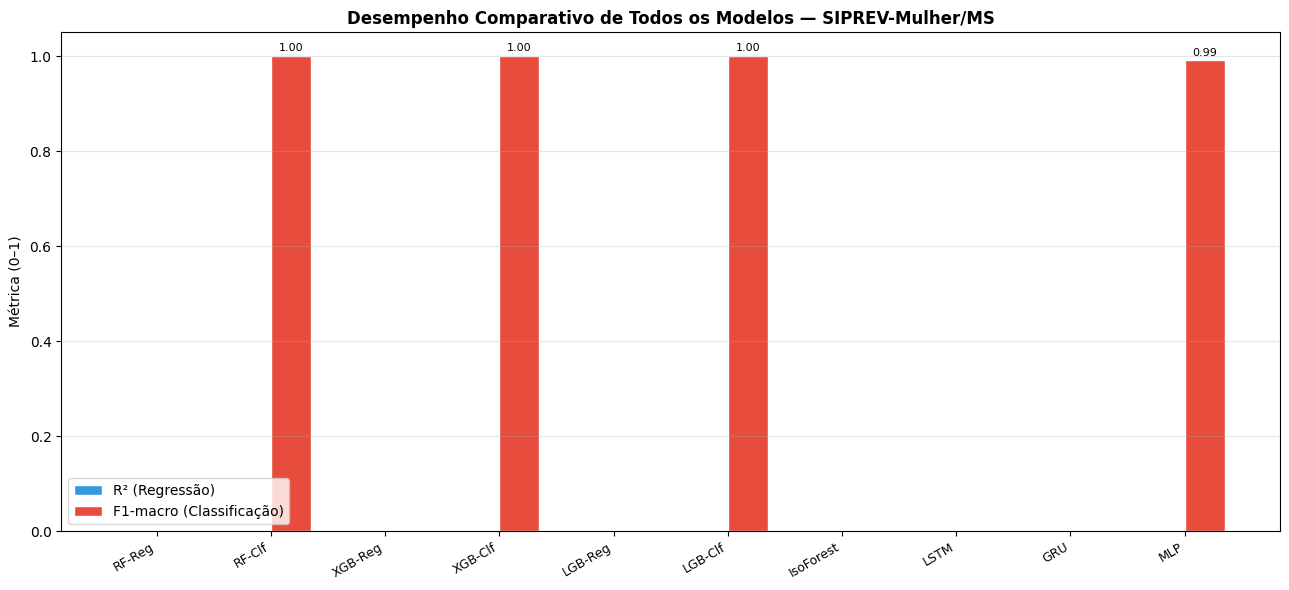

✅ D.8 Gráfico comparativo salvo


In [46]:
# ------------------------------------------------------------------
# D.8  Tabela Comparativa Final de Todos os Modelos (TXT + CSV)
# ------------------------------------------------------------------
rows_comp = []
for nome, metr in resultados_todos.items():
    tipo = metr.get("tipo","—")
    mae  = metr.get("MAE", metr.get("F1-macro", metr.get("Accuracy","—")))
    rmse = metr.get("RMSE","—")
    r2   = metr.get("R²","—")
    f1   = metr.get("F1-macro","—")
    rows_comp.append([nome, tipo, mae, rmse, r2, f1])

headers_comp = ["Modelo","Tipo","MAE / F1","RMSE","R²","F1-macro"]
txt_comp = _table_txt(headers_comp, rows_comp,
                       "COMPARATIVO DE TODOS OS MODELOS TREINADOS — SIPREV-Mulher/MS")
(REP_DIR/"D_comparativo_modelos.txt").write_text(txt_comp, encoding="utf-8")
print("✅ D.8 Comparativo de modelos (TXT): D_comparativo_modelos.txt")

pd.DataFrame([
    {"Modelo":n, "Tipo":m.get("tipo"), "MAE":m.get("MAE"),
     "RMSE":m.get("RMSE"), "R²":m.get("R²"), "F1-macro":m.get("F1-macro")}
    for n, m in resultados_todos.items()
]).to_csv(TAB_DIR/"D_comparativo_modelos.csv", index=False, encoding="utf-8-sig")

# Gráfico comparativo de modelos
fig, ax = plt.subplots(figsize=(13, 6))
nomes_m = list(resultados_todos.keys())
r2_vals  = [float(resultados_todos[m].get("R²","0") or "0") for m in nomes_m]
f1_vals  = [float(resultados_todos[m].get("F1-macro","0") or "0") for m in nomes_m]

x = np.arange(len(nomes_m))
w = 0.35
ax.bar(x-w/2, r2_vals, w, label="R² (Regressão)", color="#3498DB", edgecolor="white")
ax.bar(x+w/2, f1_vals, w, label="F1-macro (Classificação)", color="#E74C3C", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(nomes_m, rotation=30, ha="right", fontsize=9)
ax.set_title("Desempenho Comparativo de Todos os Modelos — SIPREV-Mulher/MS",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Métrica (0–1)")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)
for i, (r2, f1) in enumerate(zip(r2_vals, f1_vals)):
    if r2 > 0:
        ax.text(i-w/2, r2+0.01, f"{r2:.2f}", ha="center", fontsize=8)
    if f1 > 0:
        ax.text(i+w/2, f1+0.01, f"{f1:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(GRF_DIR/"D_comparativo_modelos.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ D.8 Gráfico comparativo salvo")

# ============================================================
# BLOCO E — EXPORTAÇÃO FINAL (ZIP COLAB / PASTAS LOCAIS)
# ============================================================


In [47]:
print("\n" + "="*70)
print("📦 BLOCO E — EXPORTAÇÃO DOS RESULTADOS")
print("="*70)

def exportar_resultados(nome_zip="siprev_resultados.zip"):
    """
    Exporta todos os resultados:
    - Google Colab: compacta em ZIP e faz download automático
    - Local: exibe sumário dos arquivos gerados
    """
    # Lista todos os arquivos gerados
    todas_pastas = [OUTPUT_DIR, MAP_DIR, REP_DIR, TAB_DIR, GRF_DIR, MODEL_DIR]
    arquivos = []
    for pasta in todas_pastas:
        if pasta.exists():
            for arq in pasta.rglob("*"):
                if arq.is_file():
                    arquivos.append(arq)

    print(f"\n📂 Total de arquivos gerados: {len(arquivos)}")

    # Agrupa por extensão
    por_ext = {}
    for a in arquivos:
        ext = a.suffix.lower() or "(sem ext)"
        por_ext.setdefault(ext, []).append(a)

    print("\n  Por tipo de arquivo:")
    for ext, lista in sorted(por_ext.items()):
        print(f"    {ext:<10s}: {len(lista):>3d} arquivo(s)")

    # Cria ZIP
    zip_path = BASE_DIR / nome_zip
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for arq in arquivos:
            arc_name = arq.relative_to(BASE_DIR)
            zf.write(arq, arc_name)
        # Inclui o CSV bruto se disponível
        csv_src = Path("crimes-violentos-letais-intencionais-sejusp.csv")
        if csv_src.exists():
            zf.write(csv_src, "data/raw/cvli_sejusp.csv")

    tamanho_mb = zip_path.stat().st_size / 1e6
    print(f"\n  📦 ZIP criado: {zip_path} ({tamanho_mb:.1f} MB)")

    if IS_COLAB:
        # Download automático no Google Colab
        from google.colab import files
        files.download(str(zip_path))
        print("  ⬇️  Download iniciado automaticamente no Colab!")
    else:
        print(f"\n  💾 Executando localmente.")
        print(f"  Acesse os resultados em: {BASE_DIR.resolve()}")
        print(f"  ZIP disponível em: {zip_path.resolve()}")

    return zip_path


def _sumario_final():
    """Exibe sumário executivo de todos os outputs."""
    print("\n" + "="*70)
    print("📋 SIPREV-Mulher/MS — SUMÁRIO FINAL DE OUTPUTS")
    print("="*70)

    categorias = {
        "🗺️  Mapas interativos (HTML)":  list(MAP_DIR.glob("*.html")),
        "📊 Gráficos (PNG)":             list(GRF_DIR.glob("*.png")),
        "📄 Relatórios (TXT)":           list(REP_DIR.glob("*.txt")),
        "📑 Tabelas (CSV)":              list(TAB_DIR.glob("*.csv")),
        "🤖 Modelos serializados":        list(MODEL_DIR.glob("*.pkl")) + list(MODEL_DIR.glob("*.h5")),
        "📈 Dashboards (HTML)":          list(OUTPUT_DIR.glob("*.html")),
    }

    for cat, arquivos in categorias.items():
        print(f"\n  {cat}: {len(arquivos)} arquivo(s)")
        for a in sorted(arquivos):
            tam = a.stat().st_size / 1024
            print(f"    {'✅' if tam>0.5 else '⏳'} {a.name:<55s} {tam:>7.1f} KB")



📦 BLOCO E — EXPORTAÇÃO DOS RESULTADOS


In [50]:
# ------------------------------------------------------------------
# E.2  Executa exportação
# ------------------------------------------------------------------
_sumario_final()
zip_gerado = exportar_resultados("SIPREV_SESUSP_Resultados.zip")



📋 SIPREV-Mulher/MS — SUMÁRIO FINAL DE OUTPUTS

  🗺️  Mapas interativos (HTML): 4 arquivo(s)
    ✅ A_mapa_feminicidio.html                                   133.3 KB
    ✅ A_mapa_taxa_100k.html                                     134.4 KB
    ✅ A_mapa_total_cvli.html                                    133.1 KB
    ✅ B4_ranking_municipal.html                                 145.4 KB

  📊 Gráficos (PNG): 13 arquivo(s)
    ✅ A2_vitimas_ano.png                                        141.4 KB
    ✅ A3_vitimas_mes.png                                        128.6 KB
    ✅ A4_faixa_etaria_vitima.png                                 87.4 KB
    ✅ A5_taxa_fem_100k.png                                      108.2 KB
    ✅ A6_bairros.png                                            264.4 KB
    ✅ A7_relacionamentos.png                                     87.9 KB
    ✅ A8_faixa_etaria_autor.png                                  92.5 KB
    ✅ B2_posicao_vs_media.png                                   169.3

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  Download iniciado automaticamente no Colab!


In [49]:
# ------------------------------------------------------------------
# E.3  Relatório executivo final (TXT)
# ------------------------------------------------------------------
total_fem = int(df_completo["flag_feminicidio"].sum())
total_fem_t = int(df_completo["flag_fem_tentada"].sum())
total_vd  = int(df_completo["flag_viol_domestica"].sum())
cidade_mais = tab_rank.iloc[0]["nm_municipio"]
cidade_menos = tab_rank.iloc[-1]["nm_municipio"]

rel_exec = f"""
{'='*80}
  SIPREV-Mulher/MS — RELATÓRIO EXECUTIVO FINAL
  Sistema Inteligente de Predição e Mapeamento da Violência contra a Mulher
  SEJUSP/MS | Mato Grosso do Sul | 2016–2025
  Disciplina: Tópicos Interdisciplinares III | UFMS Digital | 2026.1
  Gerado em: {datetime.now().strftime('%d/%m/%Y às %H:%M')}
{'='*80}

1. PANORAMA GERAL
   Período de análise      : 2016–2025 (10 anos)
   Total de ocorrências    : {len(df_completo):,} registros CVLI
   Municípios cobertos     : {df_completo['nm_municipio'].nunique()} de 79 municípios de MS
   Feminicídios consumados : {total_fem:,} casos
   Tentativas de feminicídio: {total_fem_t:,} casos
   Violência doméstica     : {total_vd:,} casos
   Média estadual (taxa)   : {media_estadual:.1f} casos /100k hab.

2. MUNICÍPIOS CRÍTICOS
   Maior volume de CVLI    : {cidade_mais} ({int(tab_rank.iloc[0]['n_total']):,} casos)
   Menor volume de CVLI    : {cidade_menos} ({int(tab_rank.iloc[-1]['n_total']):,} casos)
   Municípios Alto Risco   : {(tab_rank['classe_risco']=='🔴 Alto').sum()} municípios
   Municípios Baixo Risco  : {(tab_rank['classe_risco']=='🟢 Baixo').sum()} municípios

3. MODELOS TREINADOS
   Machine Learning        : Random Forest, XGBoost, LightGBM (Regressão + Classificação)
   Detecção de Anomalias   : Isolation Forest, Local Outlier Factor
   Deep Learning           : LSTM, GRU, MLP (Keras/TensorFlow)
   Séries Temporais        : Prophet (Meta), Auto-ARIMA

4. OUTPUTS GERADOS
   Mapas interativos (HTML): {len(list(MAP_DIR.glob('*.html')))}
   Gráficos (PNG)          : {len(list(GRF_DIR.glob('*.png')))}
   Relatórios TXT          : {len(list(REP_DIR.glob('*.txt')))}
   Tabelas CSV             : {len(list(TAB_DIR.glob('*.csv')))}
   Modelos salvos          : {len(list(MODEL_DIR.glob('*.pkl'))+list(MODEL_DIR.glob('*.h5')))}

5. RECOMENDAÇÕES PRIORITÁRIAS
   • Intensificar DEAMs e CMB nos municípios de Alto Risco
   • Protocolos binacionais para municípios de fronteira
   • Integração com Ligue 180 e SINAN para dados mais completos
   • Governança responsável dos modelos (LGPD + IA ética)
   • Revisão semestral dos modelos preditivos com dados atualizados

{'='*80}
  A tecnologia útil é aquela que resolve um problema concreto
  com responsabilidade e clareza. — SIPREV-Mulher/MS v2
{'='*80}
"""

(REP_DIR / "E_relatorio_executivo.txt").write_text(rel_exec, encoding="utf-8")
print(rel_exec)
print("\n🎉 SIPREV-Mulher/MS v2 — Análise Expandida Concluída com Sucesso!")



  SIPREV-Mulher/MS — RELATÓRIO EXECUTIVO FINAL
  Sistema Inteligente de Predição e Mapeamento da Violência contra a Mulher
  SEJUSP/MS | Mato Grosso do Sul | 2016–2025
  Disciplina: Tópicos Interdisciplinares III | UFMS Digital | 2026.1
  Gerado em: 22/05/2026 às 23:25

1. PANORAMA GERAL
   Período de análise      : 2016–2025 (10 anos)
   Total de ocorrências    : 5,005 registros CVLI
   Municípios cobertos     : 79 de 79 municípios de MS
   Feminicídios consumados : 340 casos
   Tentativas de feminicídio: 35 casos
   Violência doméstica     : 240 casos
   Média estadual (taxa)   : 180.2 casos /100k hab.

2. MUNICÍPIOS CRÍTICOS
   Maior volume de CVLI    : Campo Grande (1,298 casos)
   Menor volume de CVLI    : Jateí (2 casos)
   Municípios Alto Risco   : 12 municípios
   Municípios Baixo Risco  : 32 municípios

3. MODELOS TREINADOS
   Machine Learning        : Random Forest, XGBoost, LightGBM (Regressão + Classificação)
   Detecção de Anomalias   : Isolation Forest, Local Outlier Fac